# Enzyme-Constrained Metabolic Capability Analysis

This notebook contains the downstream analyses and publication figures for the reconstructed DSM 123 metabolic model.

Workflow:
1. Baseline FBA and flux export
2. Formate-light response scan
3. Michaelis-Menten enzyme-constrained dFBA
4. Module-capacity scaling
5. Biomass sensitivity analysis
6. Output manifest


## Inputs and outputs

### Inputs
- `../Models/purple_bacteriav_DSM123.json`: final reconstructed model
- `Supplementary File S1. DSM 123 RNA-seq DEG.xlsx`: RNA-seq abundance used for enzyme allocation
- `mm_enzyme_constraint_all_parameters_metabolites_normalized.csv`: curated kinetic constants and source records

### Unified output directory
- `publication_outputs/`

All generated SVG, PNG, CSV, and NPY files are written to this directory.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib import rcParams
from IPython.display import display

# --- Global style (publication-oriented) ---
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Arial'
rcParams['mathtext.it'] = 'Arial:italic'
rcParams['mathtext.bf'] = 'Arial:bold'
rcParams['axes.unicode_minus'] = False

MODEL_JSON = Path('../Models/purple_bacteriav_DSM123.json')
OUTPUT_DIR = Path('publication_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

assert MODEL_JSON.exists(), f'Model file not found: {MODEL_JSON}'
print(f'Model: {MODEL_JSON.resolve()}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


Model: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\Models\purple_bacteriav_DSM123.json
Output dir: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\plot\publication_outputs


In [2]:

# ---------- Shared model setup ----------

def apply_base_medium(model, oxygen_lb=-0.1, formate_bounds=(-1000.0, 1000.0), photon_lb=-1000.0):
    """Apply base physicochemical constraints used across analyses."""
    for ex in model.exchanges:
        ex.lower_bound = 0.0

    essential_ions = [
        'EX_cobalt2_e', 'EX_zn2_e', 'EX_so4_e', 'EX_ca2_e', 'EX_mn2_e',
        'EX_mg2_e', 'EX_cu2_e', 'EX_k_e', 'EX_fe3_e', 'EX_mobd_e',
        'EX_na1_e', 'EX_cl_e', 'EX_bo3_e', 'EX_pi_e', 'EX_h2o_e', 'EX_h_e', 'EX_nh4_e'
    ]
    for ion in essential_ions:
        if ion in model.reactions:
            model.reactions.get_by_id(ion).lower_bound = -1000.0

    if 'EX_co2_e' in model.reactions:
        model.reactions.get_by_id('EX_co2_e').bounds = (-1000.0, 1000.0)
    if 'EX_o2_e' in model.reactions:
        model.reactions.get_by_id('EX_o2_e').bounds = (oxygen_lb, 1000.0)
    if 'EX_for_e' in model.reactions:
        model.reactions.get_by_id('EX_for_e').bounds = formate_bounds
    if 'NTRSA' in model.reactions:
        model.reactions.get_by_id('NTRSA').bounds = (0.0, 0.0)
    if 'EX_photon_purple_e' in model.reactions:
        model.reactions.get_by_id('EX_photon_purple_e').bounds = (photon_lb, 0.0)

    # Prevent shortcut fluxes used in previous notebooks
    if 'POR5' in model.reactions:
        model.reactions.get_by_id('POR5').lower_bound = 0.0
    if 'ME2' in model.reactions:
        model.reactions.get_by_id('ME2').lower_bound = 0.0

    return model


## 1) Baseline FBA and Flux Export

In [3]:

model = cobra.io.load_json_model(str(MODEL_JSON))
model = apply_base_medium(model, oxygen_lb=-0.1, formate_bounds=(-20.0, 1000.0), photon_lb=-1000.0)
solution = model.optimize()

flux_df = solution.to_frame().reset_index().rename(columns={'index': 'reaction_id'})
flux_df.to_csv(OUTPUT_DIR / 'flux_full.csv', index=False, encoding='utf-8-sig')

exchange_df = flux_df[
    flux_df['reaction_id'].str.startswith('EX_') & (flux_df['fluxes'].abs() > 1e-9)
].sort_values('fluxes', ascending=False)
exchange_df.to_csv(OUTPUT_DIR / 'flux_exchange_nonzero.csv', index=False, encoding='utf-8-sig')

print(f'Objective value (growth): {solution.objective_value:.6f}')
display(exchange_df.head(20))


Objective value (growth): 0.268800


,reaction_id,fluxes,reduced_costs
430,EX_h2o_e,8.874667e+00,0.0
432,EX_co2_e,6.505715e+00,0.0
478,EX_pi_e,9.802431e-02,0.0
637,EX_meoh_e,2.503516e-05,0.0
451,EX_mobd_e,-5.883462e-09,0.0
447,EX_cu2_e,-8.112181e-09,0.0
2084,EX_bo3_e,-9.805283e-09,0.0
453,EX_na1_e,-3.198720e-08,-0.0
442,EX_mn2_e,-4.732131e-08,-0.0
435,EX_zn2_e,-1.977697e-07,0.0


## 2) Formate-Light Scan (Heatmaps + Linear Regression)


In [4]:

def run_formate_light_scan(model_path=MODEL_JSON, grid_size=50):
    model = cobra.io.load_json_model(str(model_path))
    model = apply_base_medium(model, oxygen_lb=-0.1, formate_bounds=(-1000.0, 1000.0), photon_lb=-1000.0)

    formate_range = np.linspace(1.0, 12.0, grid_size)
    light_range = np.linspace(1.0, 65.0, grid_size)

    res_biomass = np.zeros((grid_size, grid_size))
    res_efficiency = np.zeros((grid_size, grid_size))

    for i, for_val in enumerate(formate_range):
        with model as m:
            if 'EX_for_e' in m.reactions:
                m.reactions.get_by_id('EX_for_e').lower_bound = -float(for_val)
            for j, light_val in enumerate(light_range):
                if 'EX_photon_purple_e' in m.reactions:
                    m.reactions.get_by_id('EX_photon_purple_e').lower_bound = -float(light_val)

                obj = m.slim_optimize()
                if obj and obj > 1e-9:
                    sol = m.optimize()
                    res_biomass[i, j] = sol.objective_value
                    v_fdh = float(sol.fluxes['FDH']) if 'FDH' in sol.fluxes else 0.0
                    v_rbpc = float(sol.fluxes['RBPC']) if 'RBPC' in sol.fluxes else 0.0
                    res_efficiency[i, j] = v_rbpc / v_fdh if abs(v_fdh) > 1e-9 else 0.0

    # Save raw matrices
    np.save(OUTPUT_DIR / 'res_biomass.npy', res_biomass)
    np.save(OUTPUT_DIR / 'res_efficiency.npy', res_efficiency)
    np.save(OUTPUT_DIR / 'ranges.npy', {'formate': formate_range, 'light': light_range})

    pd.DataFrame(res_biomass, index=formate_range, columns=light_range).to_csv(
        OUTPUT_DIR / 'res_biomass_matrix.csv', encoding='utf-8-sig'
    )
    pd.DataFrame(res_efficiency, index=formate_range, columns=light_range).to_csv(
        OUTPUT_DIR / 'res_efficiency_matrix.csv', encoding='utf-8-sig'
    )

    return formate_range, light_range, res_biomass, res_efficiency


def plot_scan_results(formate_range, light_range, res_biomass, res_efficiency):
    grid_size = len(formate_range)
    tick_idx = np.linspace(0, grid_size - 1, 6).astype(int)
    x_labels = [int(light_range[k]) for k in tick_idx]
    y_labels = [int(formate_range[k]) for k in tick_idx]
    mask = (res_biomass < 1e-3)

    # Figure C: linear regression of stoichiometric inflection points
    inflection_lights, valid_formates = [], []
    for i in range(grid_size):
        row = res_biomass[i, :]
        max_v = np.max(row)
        if max_v < 1e-2:
            continue
        idx = np.where(row >= 0.99 * max_v)[0][0]
        inflection_lights.append(light_range[idx])
        valid_formates.append(formate_range[i])

    if len(inflection_lights) >= 2:
        slope, intercept, r_value, p_value, _ = stats.linregress(inflection_lights, valid_formates)
        r2 = r_value ** 2

        fig3, ax3 = plt.subplots(figsize=(10, 8))
        ax3.scatter(inflection_lights, valid_formates, color='black', alpha=0.65, s=45, label='Inflection points')
        fit_x = np.array([min(inflection_lights), max(inflection_lights)])
        fit_y = slope * fit_x + intercept
        ax3.plot(fit_x, fit_y, '--', color='#d62728', linewidth=2.5,
                 label=f'Fit: y={slope:.4f}x+({intercept:.3f}), $R^2$={r2:.4f}')
        ax3.set_xlabel(r'Light Uptake ($\mathrm{mmol\ gDCW}^{-1}\ \mathrm{h}^{-1}$)', fontsize=13, fontweight='bold')
        ax3.set_ylabel(r'Formate Uptake ($\mathrm{mmol\ gDCW}^{-1}\ \mathrm{h}^{-1}$)', fontsize=13, fontweight='bold')
        ax3.grid(True, linestyle=':', alpha=0.6)
        ax3.legend(frameon=True)
        fig3.tight_layout()
        fig3.savefig(OUTPUT_DIR / 'Analysis_Linear_Regression.svg', format='svg', bbox_inches='tight')
        plt.close(fig3)

        pd.DataFrame({
            'light_inflection': inflection_lights,
            'formate_at_inflection': valid_formates
        }).to_csv(OUTPUT_DIR / 'Analysis_Linear_Regression_data.csv', index=False, encoding='utf-8-sig')

        print(f'Linear regression: Formate = {slope:.5f} * Light + ({intercept:.5f}), R^2={r2:.5f}, p={p_value:.2e}')
    else:
        print('Not enough valid points for linear regression.')


In [5]:

formate_range, light_range, res_biomass, res_efficiency = run_formate_light_scan(MODEL_JSON, grid_size=50)
plot_scan_results(formate_range, light_range, res_biomass, res_efficiency)
print('Scan figures and tables saved to publication_outputs/.')


Linear regression: Formate = 0.19611 * Light + (-0.09957), R^2=0.99946, p=4.19e-80
Scan figures and tables saved to publication_outputs/.


## 3) Michaelis-Menten enzyme-constrained dFBA

At every dFBA step, reaction capacities are calculated from the curated kinetic CSV and the RNA-seq-allocated enzyme abundance. Direction-specific substrate terms are assigned from model stoichiometry. Intracellular metabolite concentrations retain the explicit legacy assumptions used by the original workflow.


Normalized CSV kinetics applied to 25 reactions: ['RBPCcx', 'FDH', 'RPE', 'FBA', 'FBA3', 'PGK', 'GAPD', 'TKT1', 'TKT2', 'TALA', 'SBP', 'FBP', 'TPI', 'PGM', 'ENO', 'PYK', 'CS', 'ACONT', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH', 'ME2']
Normalized CSV rows not applied: [('PRK', 'PRUK', 'missing/non-numeric kcat'), ('PGK', 'PGK', 'duplicate model reaction row')]


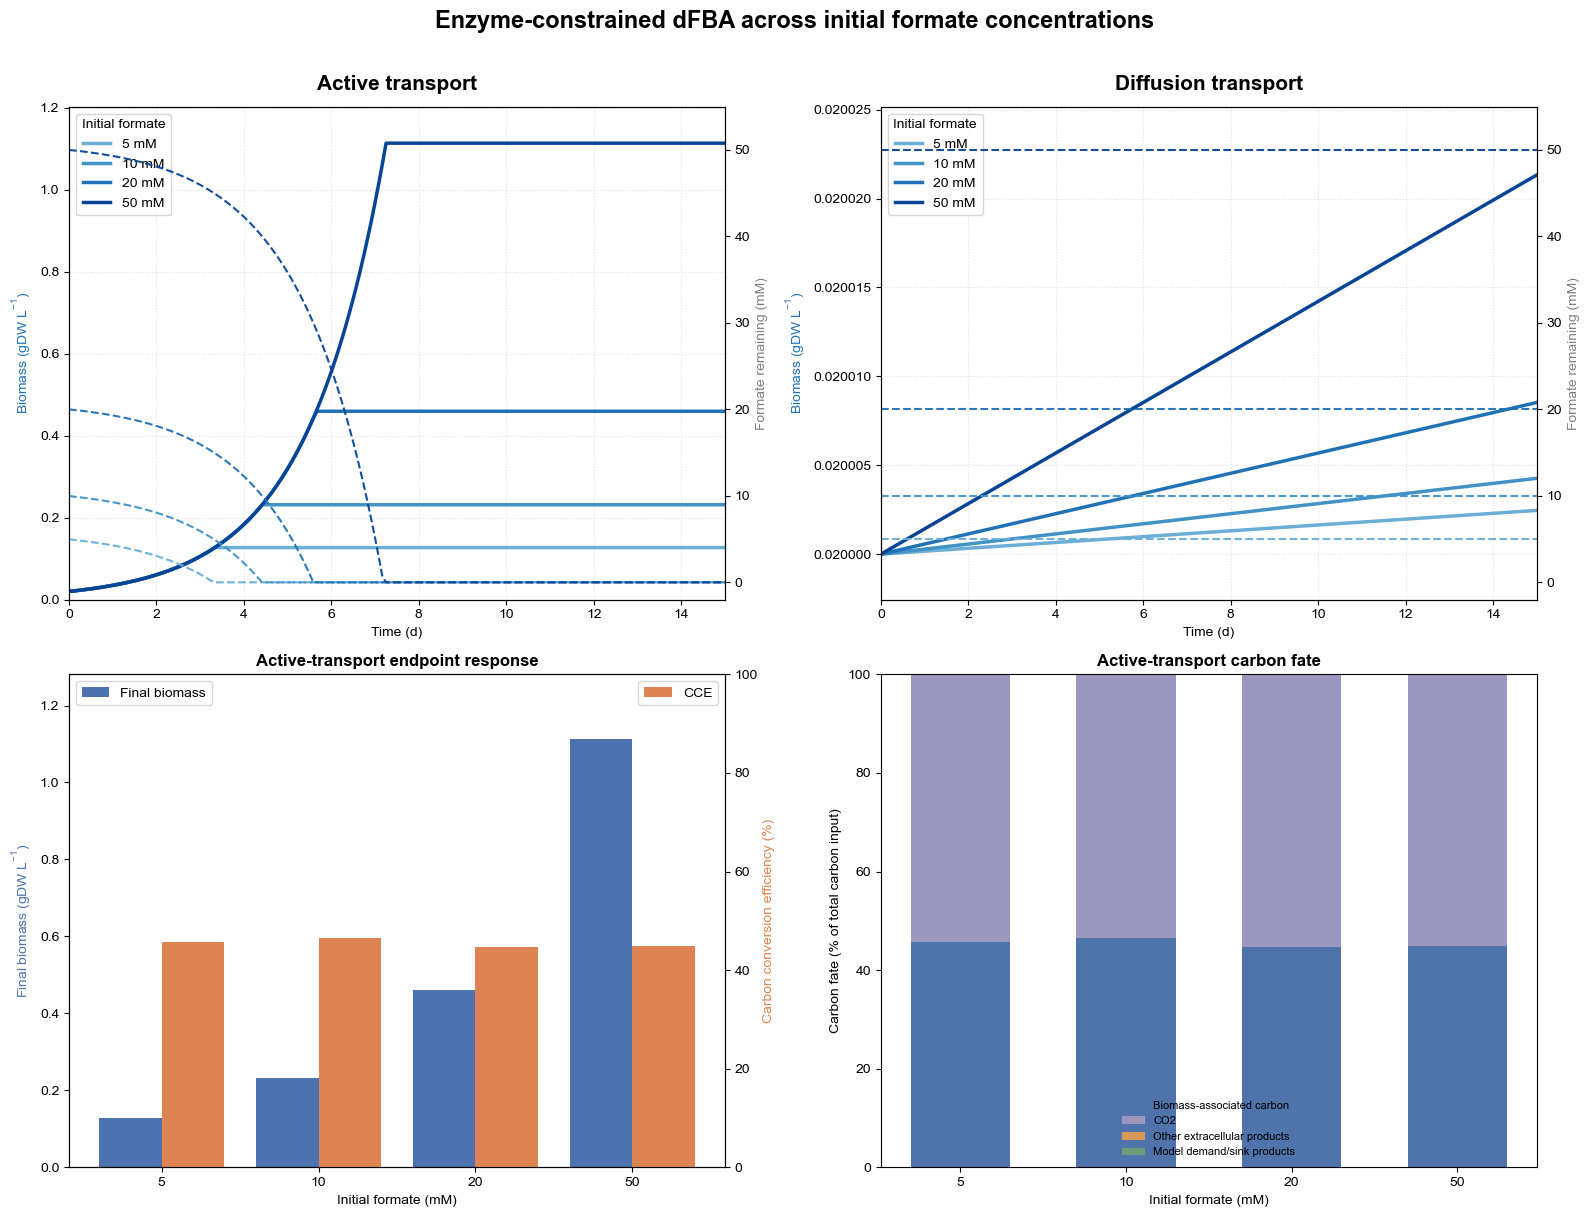

D:\ProgramData\anaconda3\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Michaelis-Menten enzyme-constrained dFBA outputs saved to: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\plot\publication_outputs
Michaelis-Menten bounds were applied to 26 CBB/TCA/FDH reactions at every dFBA step.
Final parameter table: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\plot\publication_outputs\reaction_parameters.csv
Final curve figure: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\plot\publication_outputs\mm_enzyme_constrained_dfba_20mM_active_diffusion.svg
Final abundance figure: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\plot\publication_outputs\mm_dfba_20mM_abundance_evolution_bars.svg
ForT sensitivity figure: D:\Project\ai_project\DSM123\Tn-seq\git_upload_minimal\workflow_1_model_reconstruction\plot\publication_outputs\mm_dfba_20mM_fort_parameter_sensitivity.svg
FVA line figure: D:\Project\ai_project\DS

,reaction_id,pathway,enzyme_name,ec_number,kinetic_record_status,kinetic_reference_accession,kcat_s_inv,km_mM_by_substrate,rnaseq_allocation_fraction,enzyme_umol_per_gDW,vmax_mmol_gDW_h
0,RBPCcx,CBB,Rubisco carboxylase/oxygenase mixed reaction,4.1.1.39,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,6.280,co2_c: 0.446 mM; rb15bp_c: 0.0128 mM,0.354261,1.514580,34.241624
1,FDH,Formate oxidation,Formate dehydrogenase,1.17.1.9,applied: normalized CSV kcat/Km with source link,This study,33.760,for_c: 0.38126 mM,0.031409,0.074171,9.014435
2,RPE,CBB,Ribulose-phosphate 3-epimerase,5.1.3.1,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,100.000,ru5p__D_c: 0.2 mM,0.004732,0.094791,34.124611
3,FBA,CBB,Fructose-bisphosphate aldolase,4.1.2.13,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,10.500,fdp_c: 0.17 mM,0.127175,1.637161,61.884677
4,FBA3,CBB,Sedoheptulose-bisphosphate aldolase activity,4.1.2.13,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,0.055,s17bp_c: 0.19 mM; dhap_c: 0.095 mM,0.082920,0.847771,0.167859
5,PGK,CBB,Phosphoglycerate kinase,2.7.2.3,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,149.800,3pg_c: 0.75 mM; atp_c: 0.73 mM,0.014495,0.169249,91.272465
6,GAPD,CBB,Glyceraldehyde-3-phosphate dehydrogenase,1.2.1.12,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,6.450,nadh_c: 0.048 mM,0.018060,0.250536,5.817455
7,TKT1,CBB,Transketolase,2.2.1.1,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,40.000,r5p_c: 0.12 mM; xu5p__D_c: 0.12 mM; g3p_c: 0.6...,0.052378,0.182605,26.295152
8,TKT2,CBB,Transketolase,2.2.1.1,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,671.000,e4p_c: 0.23 mM; xu5p__D_c: 0.058 mM,0.052378,0.182605,441.101173
9,TALA,CBB,Transaldolase,2.2.1.2,applied: normalized CSV kcat/Km with source link,https://www.brenda-enzymes.org/literature.php?...,13.000,g3p_c: 1.9 mM,0.028842,0.141091,6.603073


,mechanism,initial_formate_mM,final_biomass_gDW_L,final_formate_mM,final_co2_mM,formate_consumed_mM,carbon_conversion_efficiency_percent,co2_released_percent
0,Active,5,0.126973,0.000000,2.716600,5.000000,45.668003,54.331997
1,Active,10,0.231516,0.000000,5.352376,10.000000,46.476245,53.523755
2,Active,20,0.459692,0.000000,11.057765,20.000000,44.711174,55.288826
3,Active,50,1.113936,0.000000,27.521007,50.000000,44.957986,55.042014
4,Diffusion,5,0.020002,4.999904,0.000052,0.000096,46.422765,53.577235
5,Diffusion,10,0.020004,9.999808,0.000102,0.000192,46.834758,53.165242
6,Diffusion,20,0.020009,19.999615,0.000205,0.000385,46.834758,53.165242
7,Diffusion,50,0.020021,49.999038,0.000511,0.000962,46.834758,53.165242


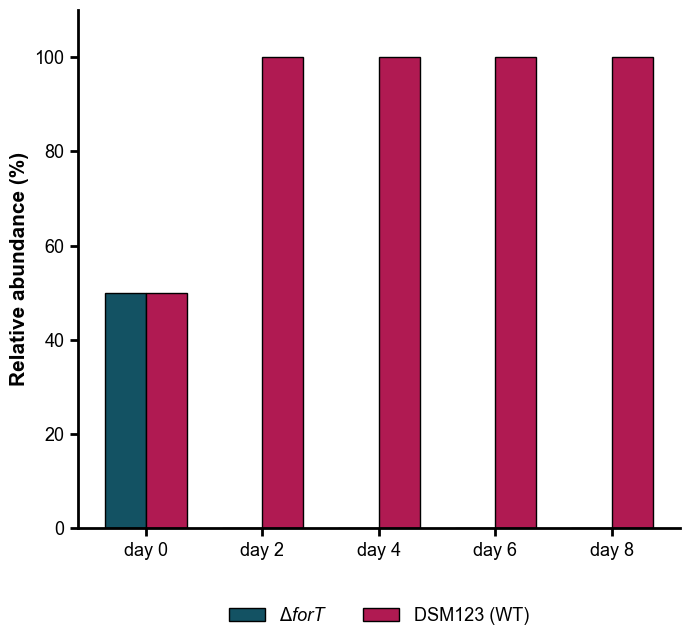

In [6]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

mpl.rcParams['svg.fonttype'] = 'none'

MM_DFBA_OUTPUT_DIR = OUTPUT_DIR
MM_DFBA_OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_JSON = Path('../Models/purple_bacteriav_DSM123.json')


def apply_base_conditions(model):
    """Apply the shared medium and reaction constraints used for the dFBA runs."""
    for ex in model.exchanges:
        ex.lower_bound = 0.0
    essential_ions = [
        'EX_cobalt2_e', 'EX_zn2_e', 'EX_so4_e', 'EX_ca2_e', 'EX_mn2_e',
        'EX_mg2_e', 'EX_cu2_e', 'EX_k_e', 'EX_fe3_e', 'EX_mobd_e',
        'EX_na1_e', 'EX_cl_e', 'EX_bo3_e', 'EX_pi_e', 'EX_h2o_e', 'EX_h_e', 'EX_nh4_e'
    ]
    for ion in essential_ions:
        if ion in model.reactions:
            model.reactions.get_by_id(ion).lower_bound = -1000.0
    if 'EX_co2_e' in model.reactions:
        model.reactions.get_by_id('EX_co2_e').bounds = (-1000.0, 1000.0)
    if 'EX_o2_e' in model.reactions:
        model.reactions.get_by_id('EX_o2_e').bounds = (-1.0, 1000.0) #Supply oxygen for the oxygenase reaction of Rubisco
    if 'NTRSA' in model.reactions:
        model.reactions.get_by_id('NTRSA').bounds = (0, 0.0)
    if 'BIOMASS__1' in model.reactions:
        model.reactions.BIOMASS__1.upper_bound = 0.023645071
    if 'EX_photon_purple_e' in model.reactions:
        model.reactions.get_by_id('EX_photon_purple_e').bounds = (-1000.0, 0.0)
    if 'POR5' in model.reactions:
        model.reactions.get_by_id('POR5').lower_bound = 0.0
    if 'ME2' in model.reactions:
        model.reactions.get_by_id('ME2').lower_bound = 0.0

    # Keep only the selected full/lumped reactions; disable duplicate alternatives.
    for reaction_id in ('RBPC', 'RBCh', 'ACONTa', 'ACONTb', 'AKGDa', 'AKGDb'):
        if reaction_id in model.reactions:
            model.reactions.get_by_id(reaction_id).bounds = (0.0, 0.0)
    return model


def _extract_locus_tags(gpr):
    return sorted(set(re.findall(r'ACXYSJ_\d+', str(gpr))))


def _load_rpal_homolog_map():
    mapping_path = Path('DSM123_blast_gene_rename_output_rpal65/rpal_to_DSM123_mapping_threshold65.csv')
    if not mapping_path.exists():
        return {}
    mapping = pd.read_csv(mapping_path)
    result = {}
    for _, row in mapping.iterrows():
        target = str(row.get('primary_target', ''))
        if target.startswith('ACXYSJ_'):
            result.setdefault(target, []).append(str(row.get('rpal_gene', '')))
    return {key: ';'.join(sorted(set(val for val in vals if val and val != 'nan'))) for key, vals in result.items()}


def _load_dsm_product_map():
    product_path = Path('DSM123_blast_gene_rename_output_rpal_pidmax/DSM123_annotation_reference_with_sequence.csv')
    if not product_path.exists():
        return {}
    ann = pd.read_csv(product_path)
    return ann.set_index('dsm_locus_tag')[['gene', 'product', 'protein_id', 'aa_length']].to_dict('index')


def substrate(metabolite_id, km_mM, default_mM, source='assumed intracellular pool'):
    return {'metabolite_id': metabolite_id, 'km_mM': km_mM, 'default_mM': default_mM, 'source': source}


# Kinetic values are placed in an explicit table so UniProt-reviewed values can be replaced directly.
# The dFBA solver uses these values through a Michaelis-Menten equation at every time step.
def kinetic_assumption(pathway, ec_number, enzyme, pools, **overrides):
    """Define reaction identity and legacy intracellular pools; kinetics are loaded from CSV."""
    item = {
        'pathway': pathway,
        'ec_number': ec_number,
        'enzyme': enzyme,
        'kcat_s_inv': np.nan,
        'enzyme_umol_per_gdw': 0.01,
        'substrates': [
            substrate(metabolite_id, np.nan, concentration_mM, 'legacy intracellular pool assumption')
            for metabolite_id, concentration_mM in pools
        ],
        'uniprot_accession_or_query': '',
        'kinetic_source': 'normalized kinetic parameter CSV',
        'kinetic_reference_accession': 'normalized kinetic parameter CSV',
        'kinetic_reference_organism_strain': 'see normalized kinetic parameter CSV',
        'kinetic_reference_note': 'kcat and Km are loaded from the normalized kinetic parameter CSV.',
        'kinetic_record_status': 'pending normalized CSV load',
        'use_mm_constraint': False,
    }
    item.update(overrides)
    return item


# Only reaction identity, legacy metabolite pools, and required RNA-seq overrides are kept here.
KINETIC_ASSUMPTIONS = {
    'RBPCcx': kinetic_assumption('CBB', '4.1.1.39', 'Rubisco carboxylase/oxygenase mixed reaction', [('co2_c', 0.01), ('rb15bp_c', 0.10)]),
    'FDH': kinetic_assumption('Formate oxidation', '1.17.1.9', 'Formate dehydrogenase', [('for_c', 10.0)], rnaseq_locus_tags_override=['PGIDNB_23465', 'PGIDNB_23470', 'PGIDNB_23475', 'PGIDNB_23480', 'PGIDNB_23485'], dsm_locus_tags_override=['ACXYSJ_23600', 'ACXYSJ_23605', 'ACXYSJ_23610', 'ACXYSJ_23615', 'ACXYSJ_23620']),
    'RPE': kinetic_assumption('CBB', '5.1.3.1', 'Ribulose-phosphate 3-epimerase', [('ru5p__D_c', 0.10)]),
    'FBA': kinetic_assumption('CBB', '4.1.2.13', 'Fructose-bisphosphate aldolase', [('fdp_c', 0.10)]),
    'FBA3': kinetic_assumption('CBB', '4.1.2.13', 'Sedoheptulose-bisphosphate aldolase activity', [('s17bp_c', 0.10), ('dhap_c', 0.10)]),
    'PGK': kinetic_assumption('CBB', '2.7.2.3', 'Phosphoglycerate kinase', [('3pg_c', 0.10), ('atp_c', 2.0)]),
    'GAPD': kinetic_assumption('CBB', '1.2.1.12', 'Glyceraldehyde-3-phosphate dehydrogenase', [('nadh_c', 0.10)]),
    'TKT1': kinetic_assumption('CBB', '2.2.1.1', 'Transketolase', [('r5p_c', 0.10), ('xu5p__D_c', 0.10), ('g3p_c', 0.10)]),
    'TKT2': kinetic_assumption('CBB', '2.2.1.1', 'Transketolase', [('e4p_c', 0.10), ('xu5p__D_c', 0.10)]),
    'TALA': kinetic_assumption('CBB', '2.2.1.2', 'Transaldolase', [('g3p_c', 0.10)]),
    'SBP': kinetic_assumption('CBB', '3.1.3.37', 'Sedoheptulose-bisphosphatase', [('s17bp_c', 0.10)]),
    'FBP': kinetic_assumption('CBB', '3.1.3.11', 'Fructose-bisphosphatase', [('fdp_c', 0.10)]),
    'TPI': kinetic_assumption('CBB', '5.3.1.1', 'Triose-phosphate isomerase', [('g3p_c', 0.10)]),
    'PRUK': kinetic_assumption('CBB', '2.7.1.19', 'Phosphoribulokinase', [('ru5p__D_c', 0.10), ('atp_c', 2.0)]),
    'PGM': kinetic_assumption('CBB', '5.4.2.12', 'Phosphoglycerate mutase', [('2pg_c', 0.10), ('3pg_c', 0.10)]),
    'ENO': kinetic_assumption('CBB', '4.2.1.11', 'Enolase', [('2pg_c', 0.10), ('pep_c', 0.10)]),
    'PYK': kinetic_assumption('CBB', '2.7.1.40', 'Pyruvate kinase', [('pep_c', 0.10), ('adp_c', 0.50)]),
    'CS': kinetic_assumption('TCA', '2.3.3.1', 'Citrate synthase', [('accoa_c', 0.20), ('oaa_c', 0.05)]),
    'ACONT': kinetic_assumption('TCA', '4.2.1.3', 'Aconitate hydratase', [('cit_c', 0.20), ('icit_c', 0.10)]),
    'ICDHyr': kinetic_assumption('TCA', '1.1.1.42', 'Isocitrate dehydrogenase (NADP)', [('icit_c', 0.10), ('nadp_c', 0.50)]),
    'AKGDH': kinetic_assumption('TCA', '1.2.4.2', '2-oxoglutarate dehydrogenase complex', [('akg_c', 0.20)]),
    'SUCOAS': kinetic_assumption('TCA', '6.2.1.5', 'Succinate-CoA ligase', [('succ_c', 0.20), ('atp_c', 2.0), ('coa_c', 0.10)]),
    'SUCDi': kinetic_assumption('TCA', '1.3.5.1', 'Succinate dehydrogenase', [('succ_c', 0.20), ('fum_c', 0.20)]),
    'FUM': kinetic_assumption('TCA', '4.2.1.2', 'Fumarase', [('fum_c', 0.20), ('mal__L_c', 0.20)]),
    'MDH': kinetic_assumption('TCA', '1.1.1.37', 'Malate dehydrogenase', [('oaa_c', 0.05), ('nadh_c', 0.10), ('nad_c', 1.0), ('mal__L_c', 0.20)]),
    'ME2': kinetic_assumption('TCA', '1.1.1.40', 'NADP-dependent malic enzyme', [('mal__L_c', 0.20), ('nadp_c', 0.50), ('nadph_c', 0.10), ('pyr_c', 0.10)]),
}


# The normalized CSV is the sole kcat/Km/reference input used by the simulations below.
# RNA-seq abundance, protein allocation, molecular mass, and intracellular pools retain the legacy workflow.
PARAMETER_CSV = Path('mm_enzyme_constraint_all_parameters_metabolites_normalized.csv')
RNA_SEQ_XLSX = Path('Supplementary File S1. DSM 123 RNA-seq DEG.xlsx')
DISABLED_ALTERNATIVE_REACTIONS = {'RBPC', 'RBCh', 'ACONTa', 'ACONTb', 'AKGDa', 'AKGDb'}


def _normalize_parameter_text(value):
    return str(value).replace(chr(0xFF1B), ';').replace(chr(0xFF1A), ':').strip()


def _parse_metabolite_values(value):
    entries = {}
    text = _normalize_parameter_text(value)
    for part in text.split(';'):
        part = part.strip()
        if ':' not in part:
            continue
        metabolite_id, raw_value = part.split(':', 1)
        match = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', raw_value)
        if match:
            entries[metabolite_id.strip()] = float(match.group())
    return entries


def _parse_kcat(value):
    text = _normalize_parameter_text(value)
    try:
        return float(text), {}
    except (TypeError, ValueError):
        directional = _parse_metabolite_values(text)
        if directional:
            return min(directional.values()), directional
        return None, {}


def _apply_normalized_parameter_csv(parameter_path=PARAMETER_CSV):
    """Override only kinetic fields; retain the legacy RNA-seq/enzyme-allocation workflow."""
    if not Path(parameter_path).exists():
        raise FileNotFoundError(f'Normalized kinetic parameter CSV not found: {parameter_path}')
    table = pd.read_csv(parameter_path, keep_default_na=False)
    required = {'reaction_id', 'model_reaction_id', 'kcat(1/s)', 'km(mM)', 'ref'}
    missing = required.difference(table.columns)
    if missing:
        raise ValueError(f'Missing required CSV columns: {sorted(missing)}')

    model_for_mapping = cobra.io.load_json_model(str(MODEL_JSON))
    global_defaults = {}
    for configured in KINETIC_ASSUMPTIONS.values():
        for item in configured.get('substrates', []):
            global_defaults.setdefault(item['metabolite_id'], item.get('default_mM', 0.10))

    applied, skipped, seen = [], [], set()
    for _, row in table.iterrows():
        source_label = str(row.get('reaction_id', '')).strip()
        rid = str(row.get('model_reaction_id', '')).strip() or source_label
        if not rid or rid.lower() == 'nan' or rid == 'EX_for_e':
            continue
        if rid in seen:
            skipped.append((source_label, rid, 'duplicate model reaction row'))
            continue
        seen.add(rid)
        if rid in DISABLED_ALTERNATIVE_REACTIONS:
            if rid in KINETIC_ASSUMPTIONS:
                KINETIC_ASSUMPTIONS[rid]['use_mm_constraint'] = False
            skipped.append((source_label, rid, 'disabled alternative/split reaction'))
            continue
        if rid not in model_for_mapping.reactions:
            skipped.append((source_label, rid, 'model reaction not found'))
            continue
        if rid not in KINETIC_ASSUMPTIONS:
            skipped.append((source_label, rid, 'reaction is not registered for enzyme constraint'))
            continue

        kcat, directional_kcat = _parse_kcat(row.get('kcat(1/s)', ''))
        if kcat is None or not np.isfinite(kcat):
            KINETIC_ASSUMPTIONS[rid]['use_mm_constraint'] = False
            KINETIC_ASSUMPTIONS[rid]['kinetic_record_status'] = 'not applied: kcat missing in normalized CSV'
            skipped.append((source_label, rid, 'missing/non-numeric kcat'))
            continue

        reaction = model_for_mapping.reactions.get_by_id(rid)
        model_metabolites = {met.id for met in reaction.metabolites}
        km_entries = _parse_metabolite_values(row.get('km(mM)', ''))
        exact_km = {mid: value for mid, value in km_entries.items() if mid in model_metabolites}
        ignored_km = {mid: value for mid, value in km_entries.items() if mid not in model_metabolites}
        if not exact_km:
            KINETIC_ASSUMPTIONS[rid]['use_mm_constraint'] = False
            skipped.append((source_label, rid, 'no Km metabolite matches the model reaction'))
            continue

        kinetic = KINETIC_ASSUMPTIONS[rid]
        old_by_metabolite = {item['metabolite_id']: item for item in kinetic.get('substrates', [])}
        ref = str(row.get('ref', '')).strip()
        new_substrates = []
        for metabolite_id, km_value in exact_km.items():
            default = old_by_metabolite.get(metabolite_id, {}).get(
                'default_mM', global_defaults.get(metabolite_id, 0.10)
            )
            new_substrates.append(substrate(
                metabolite_id, km_value, default,
                f'Km from normalized CSV; BRENDA/source record: {ref}',
            ))

        kinetic['kcat_s_inv'] = kcat
        kinetic['directional_kcat_s_inv'] = {
            mid: value for mid, value in directional_kcat.items() if mid in model_metabolites
        }
        kinetic['substrates'] = new_substrates
        kinetic['kinetic_source'] = ref
        kinetic['kinetic_reference_accession'] = ref
        kinetic['kinetic_reference_organism_strain'] = str(row.get('reference_organism', '')).strip()
        kinetic['kinetic_reference_note'] = 'Kinetic fields loaded from mm_enzyme_constraint_all_parameters_metabolites_normalized.csv.'
        kinetic['kinetic_record_status'] = 'applied: normalized CSV kcat/Km with source link'
        kinetic['use_mm_constraint'] = True
        kinetic['parameter_input_file'] = Path(parameter_path).name
        kinetic['source_csv_reaction_id'] = source_label
        kinetic['ignored_nonreaction_km_entries'] = ignored_km
        applied.append(rid)

    for rid in DISABLED_ALTERNATIVE_REACTIONS:
        if rid in KINETIC_ASSUMPTIONS:
            KINETIC_ASSUMPTIONS[rid]['use_mm_constraint'] = False
    print(f'Normalized CSV kinetics applied to {len(applied)} reactions: {applied}')
    if skipped:
        print(f'Normalized CSV rows not applied: {skipped}')
    return table, applied, skipped


USER_PARAMETER_TABLE, USER_PARAMETER_REACTIONS, USER_PARAMETER_SKIPPED = _apply_normalized_parameter_csv()


def _directional_kcat_values(reaction, kinetic):
    base = float(kinetic['kcat_s_inv'])
    directional = kinetic.get('directional_kcat_s_inv', {})
    forward_values, reverse_values = [], []
    model_metabolite_ids = {met.id for met in reaction.metabolites}
    for metabolite_id, value in directional.items():
        if metabolite_id not in model_metabolite_ids:
            continue
        coefficient = float(reaction.get_coefficient(metabolite_id))
        if coefficient < 0:
            forward_values.append(float(value))
        elif coefficient > 0:
            reverse_values.append(float(value))
    return (
        min(forward_values) if forward_values else base,
        min(reverse_values) if reverse_values else base,
    )

def build_mm_kinetics_table(model):
    rpal_map = _load_rpal_homolog_map()
    product_map = _load_dsm_product_map()
    rows = []
    substrate_rows = []
    for rid, kinetic in KINETIC_ASSUMPTIONS.items():
        if rid not in model.reactions:
            continue
        rxn = model.reactions.get_by_id(rid)
        locus_tags = kinetic.get('dsm_locus_tags_override') or _extract_locus_tags(rxn.gene_reaction_rule)
        products, protein_ids, aa_lengths = [], [], []
        for locus in locus_tags:
            ann = product_map.get(locus, {})
            if ann:
                products.append(f"{locus}:{ann.get('product', '')}")
                protein_ids.append(str(ann.get('protein_id', '')))
                aa_lengths.append(str(ann.get('aa_length', '')))
        rpal_homologs = ';'.join(sorted(set(rpal_map.get(locus, '') for locus in locus_tags if rpal_map.get(locus, ''))))
        kcat_forward, kcat_reverse = _directional_kcat_values(rxn, kinetic)
        vmax_forward = kcat_forward * (kinetic['enzyme_umol_per_gdw'] / 1000.0) * 3600.0
        vmax_reverse = kcat_reverse * (kinetic['enzyme_umol_per_gdw'] / 1000.0) * 3600.0
        vmax_mmol_gdw_h = max(vmax_forward, vmax_reverse)
        rows.append({
            'reaction_id': rid,
            'reaction_name': rxn.name,
            'pathway': kinetic['pathway'],
            'ec_number': kinetic['ec_number'],
            'enzyme_name': kinetic['enzyme'],
            'dsm_locus_tags': ';'.join(locus_tags),
            'dsm_products': ';'.join(products),
            'dsm_protein_ids': ';'.join(protein_ids),
            'dsm_aa_lengths': ';'.join(aa_lengths),
            'rpal_homolog_locus_tags': rpal_homologs,
            'uniprot_accession_or_query': kinetic['uniprot_accession_or_query'],
            'kinetic_source': kinetic['kinetic_source'],
            'kinetic_reference_accession': kinetic.get('kinetic_reference_accession', kinetic.get('uniprot_accession_or_query', 'not resolved')),
            'kinetic_reference_organism_strain': kinetic.get('kinetic_reference_organism_strain', 'not resolved'),
            'kinetic_reference_note': kinetic.get('kinetic_reference_note', kinetic['kinetic_source']),
            'kinetic_record_status': kinetic.get('kinetic_record_status', 'not verified'),
            'use_mm_constraint': kinetic.get('use_mm_constraint', False),
            'kcat_s_inv': kinetic['kcat_s_inv'],
            'kcat_forward_s_inv': kcat_forward,
            'kcat_reverse_s_inv': kcat_reverse,
            'directional_kcat_by_substrate': ';'.join(f'{mid}:{value:g}' for mid, value in kinetic.get('directional_kcat_s_inv', {}).items()),
            'parameter_input_file': kinetic.get('parameter_input_file', ''),
            'source_csv_reaction_id': kinetic.get('source_csv_reaction_id', rid),
            'ignored_nonreaction_km_entries': ';'.join(f'{mid}:{value:g}' for mid, value in kinetic.get('ignored_nonreaction_km_entries', {}).items()),
            'pgidnb_locus_tags': kinetic.get('pgidnb_locus_tags', ''),
            'rnaseq_6h_median_expression': kinetic.get('rnaseq_6h_median_expression', np.nan),
            'rnaseq_total_expression_for_constrained_reactions': kinetic.get('rnaseq_total_expression_for_constrained_reactions', np.nan),
            'rnaseq_allocation_fraction': kinetic.get('rnaseq_allocation_fraction', np.nan),
            'model_biomass_protein_fraction_g_per_gdw': kinetic.get('model_biomass_protein_fraction_g_per_gdw', np.nan),
            'enzyme_pool_fraction_of_biomass_protein': kinetic.get('enzyme_pool_fraction_of_biomass_protein', np.nan),
            'estimated_enzyme_mw_kda': kinetic.get('estimated_enzyme_mw_kda', np.nan),
            'allocated_enzyme_mass_g_per_gdw': kinetic.get('allocated_enzyme_mass_g_per_gdw', np.nan),
            'enzyme_umol_per_gdw': kinetic['enzyme_umol_per_gdw'],
            'vmax_mmol_gdw_h': vmax_mmol_gdw_h,
            'vmax_forward_mmol_gdw_h': vmax_forward,
            'vmax_reverse_mmol_gdw_h': vmax_reverse,
            'mm_formula': 'v = kcat_s_inv * (enzyme_umol_per_gdw / 1000) * 3600 * min(S_i / (Km_i + S_i))',
            'substrates': ';'.join(s['metabolite_id'] for s in kinetic['substrates']),
            'gene_reaction_rule': rxn.gene_reaction_rule,
        })
        for s in kinetic['substrates']:
            substrate_rows.append({
                'reaction_id': rid,
                'metabolite_id': s['metabolite_id'],
                'km_mM': s['km_mM'],
                'default_concentration_mM': s['default_mM'],
                'concentration_source': s['source'],
            })
    return pd.DataFrame(rows), pd.DataFrame(substrate_rows)


def _biomass_protein_fraction_g_per_gdw(model):
    """Read the protein mass fraction directly from the biomass reaction."""
    if 'BIOMASS__1' not in model.reactions:
        return 0.5112
    biomass = model.reactions.get_by_id('BIOMASS__1')
    for metabolite, coefficient in biomass.metabolites.items():
        if metabolite.id == 'bm_pro_c':
            return abs(float(coefficient))
    return 0.5112


def _estimate_enzyme_mw_kda(locus_tags, product_map):
    """Approximate enzyme molecular weight from GPR-associated protein lengths."""
    aa_lengths = []
    for locus in locus_tags:
        ann = product_map.get(locus, {})
        value = ann.get('aa_length', np.nan)
        if pd.notna(value):
            aa_lengths.append(float(value))
    if not aa_lengths:
        return 50.0
    mw_kda = sum(aa_lengths) * 0.110
    return mw_kda if mw_kda > 0 else 50.0


def apply_rnaseq_enzyme_scaling(model, rnaseq_path=None, enzyme_pool_fraction_of_biomass_protein=1.0):
    """Allocate the biomass protein pool to constrained reactions using RNA-seq relative abundance."""
    if rnaseq_path is None:
        rnaseq_path = MM_DFBA_OUTPUT_DIR / 'Supplementary File S1. DSM 123 RNA-seq DEG.xlsx'
    rnaseq_path = Path(rnaseq_path)
    mapping_path = rnaseq_path.parent / 'DSM123_blast_gene_rename_output' / 'gene_mapping_consensus_to_DSM123.csv'
    product_map = _load_dsm_product_map()
    protein_fraction_g_per_gdw = _biomass_protein_fraction_g_per_gdw(model)
    rows = []
    if not rnaseq_path.exists():
        raise FileNotFoundError(f'RNA-seq input required for enzyme allocation: {rnaseq_path}')
    if not mapping_path.exists():
        raise FileNotFoundError(f'Gene mapping required for RNA-seq enzyme allocation: {mapping_path}')

    mapping = pd.read_csv(mapping_path)
    dsm_to_pgid = (
        mapping.dropna(subset=['subject_locus_tag', 'query_locus_tag'])
        .groupby('subject_locus_tag')['query_locus_tag']
        .apply(lambda x: sorted(set(map(str, x))))
        .to_dict()
    )
    rnaseq = pd.read_excel(rnaseq_path, sheet_name='123 0h vs 6h')
    expr_cols = [c for c in rnaseq.columns if str(c).endswith('-6h')]
    rnaseq['rnaseq_6h_mean'] = rnaseq[expr_cols].mean(axis=1)
    expr = dict(zip(rnaseq['ID'].astype(str), rnaseq['rnaseq_6h_mean']))

    for rid, kinetic in KINETIC_ASSUMPTIONS.items():
        if rid not in model.reactions:
            continue
        locus_tags = kinetic.get('dsm_locus_tags_override') or _extract_locus_tags(model.reactions.get_by_id(rid).gene_reaction_rule)
        pgids, values = [], []
        override_pgids = kinetic.get('rnaseq_locus_tags_override')
        if override_pgids:
            pgids = list(override_pgids)
            for pgid in pgids:
                value = expr.get(pgid, np.nan)
                if pd.notna(value):
                    values.append(float(value))
        else:
            for locus in locus_tags:
                for pgid in dsm_to_pgid.get(locus, []):
                    pgids.append(pgid)
                    value = expr.get(pgid, np.nan)
                    if pd.notna(value):
                        values.append(float(value))
        score = float(np.median(values)) if values else np.nan
        mw_kda = _estimate_enzyme_mw_kda(locus_tags, product_map)
        rows.append({
            'reaction_id': rid,
            'pgidnb_locus_tags': ';'.join(sorted(set(pgids))),
            'rnaseq_6h_median_expression': score,
            'estimated_enzyme_mw_kda': mw_kda,
        })

    scaling_df = pd.DataFrame(rows)
    total_score = float(scaling_df['rnaseq_6h_median_expression'].dropna().sum())
    if total_score <= 0:
        total_score = float(len(scaling_df))
    total_enzyme_mass_g_per_gdw = protein_fraction_g_per_gdw * enzyme_pool_fraction_of_biomass_protein

    for _, row in scaling_df.iterrows():
        rid = row['reaction_id']
        score = row['rnaseq_6h_median_expression']
        allocation = float(score / total_score) if pd.notna(score) and total_score > 0 else 1.0 / max(len(scaling_df), 1)
        allocated_mass = total_enzyme_mass_g_per_gdw * allocation
        mw_kda = float(row['estimated_enzyme_mw_kda'])
        if mw_kda <= 0:
            mw_kda = 50.0
        enzyme_umol = allocated_mass / (mw_kda * 1000.0) * 1e6
        KINETIC_ASSUMPTIONS[rid]['pgidnb_locus_tags'] = row['pgidnb_locus_tags']
        KINETIC_ASSUMPTIONS[rid]['rnaseq_6h_median_expression'] = score
        KINETIC_ASSUMPTIONS[rid]['rnaseq_total_expression_for_constrained_reactions'] = total_score
        KINETIC_ASSUMPTIONS[rid]['rnaseq_allocation_fraction'] = allocation
        KINETIC_ASSUMPTIONS[rid]['model_biomass_protein_fraction_g_per_gdw'] = protein_fraction_g_per_gdw
        KINETIC_ASSUMPTIONS[rid]['enzyme_pool_fraction_of_biomass_protein'] = enzyme_pool_fraction_of_biomass_protein
        KINETIC_ASSUMPTIONS[rid]['estimated_enzyme_mw_kda'] = mw_kda
        KINETIC_ASSUMPTIONS[rid]['allocated_enzyme_mass_g_per_gdw'] = allocated_mass
        KINETIC_ASSUMPTIONS[rid]['enzyme_umol_per_gdw'] = enzyme_umol
    return scaling_df


def _concentration_map(formate_mM, co2_mM):
    concentration = {}
    for kinetic in KINETIC_ASSUMPTIONS.values():
        for s in kinetic['substrates']:
            concentration[s['metabolite_id']] = s['default_mM']
    concentration['for_e'] = max(formate_mM, 0.0)
    concentration['for_c'] = max(formate_mM, 0.0)
    concentration['co2_c'] = max(0.01, 0.01 + max(co2_mM, 0.0))
    concentration['o2_c'] = 0.25
    return concentration


def _directional_mm_bounds(reaction, kinetic, concentration):
    """Calculate forward/reverse MM bounds from exact model-metabolite kinetic terms."""
    enzyme_umol_per_gdw = kinetic['enzyme_umol_per_gdw']
    kcat_forward, kcat_reverse = _directional_kcat_values(reaction, kinetic)
    vmax_forward = kcat_forward * (enzyme_umol_per_gdw / 1000.0) * 3600.0
    vmax_reverse = kcat_reverse * (enzyme_umol_per_gdw / 1000.0) * 3600.0
    forward_factors, reverse_factors, details = [], [], []
    for item in kinetic['substrates']:
        metabolite_id = item['metabolite_id']
        substrate_conc = float(concentration.get(metabolite_id, item['default_mM']))
        km = float(item['km_mM'])
        factor = substrate_conc / (km + substrate_conc) if substrate_conc > 0 else 0.0
        coefficient = float(reaction.get_coefficient(metabolite_id))
        if coefficient < 0:
            direction = 'forward'
            forward_factors.append(factor)
        elif coefficient > 0:
            direction = 'reverse'
            reverse_factors.append(factor)
        else:
            direction = 'unmapped'
        details.append(
            f'{metabolite_id}:direction={direction},S={substrate_conc:.6g},Km={km:.6g},sat={factor:.6g}'
        )
    forward_saturation = min(forward_factors) if forward_factors else 1.0
    reverse_saturation = min(reverse_factors) if reverse_factors else 1.0
    details.append(f'kcat_forward={kcat_forward:.6g};kcat_reverse={kcat_reverse:.6g}')
    return (
        vmax_forward * forward_saturation,
        vmax_reverse * reverse_saturation,
        max(vmax_forward, vmax_reverse),
        forward_saturation,
        reverse_saturation,
        ';'.join(details),
    )

def apply_mm_constraints(model, concentration, time_h, mechanism, initial_formate_mM):
    records = []
    for rid, kinetic in KINETIC_ASSUMPTIONS.items():
        if rid not in model.reactions or not kinetic.get('use_mm_constraint', False):
            continue
        reaction = model.reactions.get_by_id(rid)
        forward_bound, reverse_bound, vmax, forward_sat, reverse_sat, details = _directional_mm_bounds(
            reaction, kinetic, concentration
        )
        old_lb, old_ub = reaction.lower_bound, reaction.upper_bound
        if old_lb < 0:
            reaction.lower_bound = max(old_lb, -reverse_bound)
        else:
            reaction.lower_bound = max(old_lb, 0.0)
        if old_ub > 0:
            reaction.upper_bound = min(old_ub, forward_bound)
        else:
            reaction.upper_bound = min(old_ub, 0.0)
        records.append({
            'time_h': time_h,
            'mechanism': mechanism,
            'initial_formate_mM': initial_formate_mM,
            'reaction_id': rid,
            'pathway': kinetic['pathway'],
            'vmax_mmol_gdw_h': vmax,
            'forward_mm_bound_mmol_gdw_h': forward_bound,
            'reverse_mm_bound_mmol_gdw_h': reverse_bound,
            'forward_saturation_factor': forward_sat,
            'reverse_saturation_factor': reverse_sat,
            'mm_effective_bound_mmol_gdw_h': max(forward_bound, reverse_bound),
            'limiting_saturation_factor': min(forward_sat, reverse_sat),
            'substrate_terms': details,
            'old_lower_bound': old_lb,
            'old_upper_bound': old_ub,
            'new_lower_bound': reaction.lower_bound,
            'new_upper_bound': reaction.upper_bound,
        })
    return records

def run_mm_enzyme_constrained_dfba(model_path=MODEL_JSON, output_dir=MM_DFBA_OUTPUT_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    base_model = cobra.io.load_json_model(str(model_path))
    base_model = apply_base_conditions(base_model)
    base_model.objective = 'BIOMASS__1'

    rnaseq_scaling_df = apply_rnaseq_enzyme_scaling(base_model, RNA_SEQ_XLSX, enzyme_pool_fraction_of_biomass_protein=1.0)
    rnaseq_scaling_df.to_csv(output_dir / 'rnaseq_allocation.csv', index=False, encoding='utf-8-sig')
    kinetics_df, substrate_df = build_mm_kinetics_table(base_model)
    kinetics_df.to_csv(output_dir / 'kinetics.csv', index=False, encoding='utf-8-sig')
    substrate_df.to_csv(output_dir / 'substrates.csv', index=False, encoding='utf-8-sig')

    t_max, dt = 360, 2.0
    x0 = 0.02
    initial_formates = [5, 10, 20, 50]
    mechanisms = ['Active', 'Diffusion']
    vmax_transport = 1.786555464
    km_fort = 0.01814
    p_envelope = 1.0e-8
    area_spec_nichols = 1.32e5
    diff_conv = p_envelope * area_spec_nichols * 3600 / 1000
    pka_formic, ph_env = 3.75, 7.0
    total_light, max_specific_light = 50.0, 60.0

    all_results = {mech: {} for mech in mechanisms}
    records = []
    flux_records = []
    bound_records = []
    constrained_reactions = [rid for rid, kinetic in KINETIC_ASSUMPTIONS.items() if rid in base_model.reactions and kinetic.get('use_mm_constraint', False)]
    carbon_boundary_metadata = []
    for boundary_rxn in base_model.boundary:
        boundary_metabolites = list(boundary_rxn.metabolites)
        if len(boundary_metabolites) != 1:
            continue
        boundary_metabolite = boundary_metabolites[0]
        carbon_atoms = float((boundary_metabolite.elements or {}).get('C', 0) or 0)
        if carbon_atoms <= 0:
            continue
        carbon_boundary_metadata.append({
            'reaction_id': boundary_rxn.id,
            'metabolite_id': boundary_metabolite.id,
            'destination_name': boundary_metabolite.name,
            'carbon_atoms': carbon_atoms,
            'stoichiometric_coefficient': float(boundary_rxn.metabolites[boundary_metabolite]),
            'is_exchange': boundary_rxn.id.startswith('EX_'),
        })
    carbon_boundary_totals = {}

    for mech in mechanisms:
        for init_for in initial_formates:
            x, formate, co2 = x0, float(init_for), 0.0
            history = {'time': [], 'X': [], 'For': [], 'CO2': []}
            trajectory_carbon_totals = {
                item['reaction_id']: {'output_mmol_C_L': 0.0, 'input_mmol_C_L': 0.0}
                for item in carbon_boundary_metadata
            }
            for t in np.arange(0, t_max + dt, dt):
                if formate > 1e-4:
                    if mech == 'Active':
                        v_uptake = vmax_transport * (formate / (km_fort + formate))
                    else:
                        frac_undiss = 1.0 / (1.0 + 10 ** (ph_env - pka_formic))
                        v_uptake = diff_conv * (formate * frac_undiss)
                else:
                    v_uptake = 0.0

                concentration = _concentration_map(formate, co2)
                with base_model as m:
                    bound_records.extend(apply_mm_constraints(m, concentration, t, mech, init_for))
                    m.reactions.get_by_id('EX_for_e').lower_bound = -v_uptake
                    if 'EX_photon_purple_e' in m.reactions:
                        m.reactions.get_by_id('EX_photon_purple_e').lower_bound = -min(max_specific_light, total_light / max(x, 1e-12))

                    sol_value = m.slim_optimize()
                    if sol_value and sol_value > 1e-9:
                        full_sol = m.optimize()
                        mu = float(full_sol.objective_value)
                        f_for = float(full_sol.fluxes.get('EX_for_e', 0.0))
                        f_co2 = float(full_sol.fluxes.get('EX_co2_e', 0.0))
                        integration_biomass = x + mu * x * dt
                        for boundary_item in carbon_boundary_metadata:
                            boundary_flux = float(full_sol.fluxes.get(boundary_item['reaction_id'], 0.0))
                            outward_rate = -boundary_item['stoichiometric_coefficient'] * boundary_flux
                            carbon_amount = (
                                outward_rate * integration_biomass * dt
                                * boundary_item['carbon_atoms']
                            )
                            totals = trajectory_carbon_totals[boundary_item['reaction_id']]
                            if carbon_amount > 0:
                                totals['output_mmol_C_L'] += carbon_amount
                            elif carbon_amount < 0:
                                totals['input_mmol_C_L'] += -carbon_amount
                        for rid in constrained_reactions:
                            flux_records.append({
                                'mechanism': mech,
                                'initial_formate_mM': init_for,
                                'time_h': t,
                                'reaction_id': rid,
                                'flux_mmol_gDW_h': float(full_sol.fluxes.get(rid, 0.0)),
                            })
                    else:
                        mu, f_for, f_co2 = 0.0, 0.0, 0.0

                history['time'].append(t)
                history['X'].append(x)
                history['For'].append(formate)
                history['CO2'].append(co2)
                records.append({
                    'mechanism': mech,
                    'initial_formate_mM': init_for,
                    'time_h': t,
                    'biomass_gDW_L': x,
                    'formate_mM': formate,
                    'co2_mM': co2,
                    'mu_h_inv': mu,
                    'formate_exchange_flux': f_for,
                    'co2_exchange_flux': f_co2,
                    'formate_uptake_capacity': v_uptake,
                    'co2_proxy_mM_for_mm': concentration['co2_c'],
                })
                x += mu * x * dt
                formate += f_for * x * dt
                co2 += f_co2 * x * dt
                if formate < 0:
                    formate = 0.0
            all_results[mech][init_for] = history
            carbon_boundary_totals[(mech, init_for)] = trajectory_carbon_totals

    time_df = pd.DataFrame(records)
    time_df['time_d'] = time_df['time_h'] / 24.0
    formate_series_columns = [
        'mechanism', 'initial_formate_mM', 'time_h', 'time_d',
        'biomass_gDW_L', 'formate_mM', 'co2_mM',
    ]
    try:
        time_df[formate_series_columns].to_csv(
            output_dir / 'mm_enzyme_constrained_dfba_formate_series_data.csv',
            index=False,
        )
    except PermissionError:
        print('Formate-series CSV is open; keeping the existing file and continuing.')
    flux_df = pd.DataFrame(flux_records)
    bounds_df = pd.DataFrame(bound_records)
    summary_rows = []
    for mech in mechanisms:
        for init_for in initial_formates:
            h = all_results[mech][init_for]
            summary_rows.append({
                'mechanism': mech,
                'initial_formate_mM': init_for,
                'final_biomass_gDW_L': h['X'][-1],
                'final_formate_mM': h['For'][-1],
                'final_co2_mM': h['CO2'][-1],
            })
    summary_df = pd.DataFrame(summary_rows)
    summary_df['formate_consumed_mM'] = (
        summary_df['initial_formate_mM'] - summary_df['final_formate_mM']
    )
    summary_df['carbon_conversion_efficiency_percent'] = 100.0 * (
        summary_df['formate_consumed_mM'] - summary_df['final_co2_mM']
    ) / summary_df['formate_consumed_mM'].clip(lower=1e-9)
    summary_df['co2_released_percent'] = 100.0 * summary_df['final_co2_mM'] / (
        summary_df['formate_consumed_mM'].clip(lower=1e-9)
    )
    try:
        summary_df.to_csv(
            output_dir / 'mm_enzyme_constrained_dfba_formate_series_bar_data.csv',
            index=False,
        )
    except PermissionError:
        print('Endpoint bar-data CSV is open; skipping its refresh for this run.')

    carbon_fate_rows = []
    metadata_by_reaction = {
        item['reaction_id']: item for item in carbon_boundary_metadata
    }
    for init_for in initial_formates:
        history = all_results['Active'][init_for]
        totals = carbon_boundary_totals[('Active', init_for)]
        residual_formate = float(history['For'][-1])
        external_carbon_input = sum(
            values['input_mmol_C_L']
            for rid, values in totals.items()
            if rid != 'EX_for_e'
        )
        total_carbon_input = float(init_for) + external_carbon_input
        classified_output = residual_formate
        destination_rows = []
        for rid, values in totals.items():
            amount = float(values['output_mmol_C_L'])
            if rid == 'EX_for_e' or amount <= 1e-12:
                continue
            item = metadata_by_reaction[rid]
            if rid == 'EX_co2_e':
                destination_class = 'CO2'
            elif item['is_exchange']:
                destination_class = 'Other extracellular products'
            else:
                destination_class = 'Model demand/sink products'
            classified_output += amount
            destination_rows.append({
                'destination_class': destination_class,
                'reaction_id': rid,
                'metabolite_id': item['metabolite_id'],
                'destination_name': item['destination_name'],
                'carbon_mmol_L': amount,
            })

        biomass_associated_carbon = max(total_carbon_input - classified_output, 0.0)
        destination_rows.extend([
            {
                'destination_class': 'Biomass-associated carbon',
                'reaction_id': 'carbon_balance_residual',
                'metabolite_id': 'biomass',
                'destination_name': 'Biomass-associated carbon (balance residual)',
                'carbon_mmol_L': biomass_associated_carbon,
            },
            {
                'destination_class': 'Residual formate',
                'reaction_id': 'EX_for_e',
                'metabolite_id': 'for_e',
                'destination_name': 'Residual formate',
                'carbon_mmol_L': residual_formate,
            },
        ])
        if not any(row['destination_class'] == 'Other extracellular products' for row in destination_rows):
            destination_rows.append({
                'destination_class': 'Other extracellular products',
                'reaction_id': 'none_detected',
                'metabolite_id': '',
                'destination_name': 'No other extracellular carbon product detected',
                'carbon_mmol_L': 0.0,
            })
        for row in destination_rows:
            row.update({
                'initial_formate_mM': init_for,
                'total_carbon_input_mmol_C_L': total_carbon_input,
                'external_carbon_uptake_mmol_C_L': external_carbon_input,
                'percent_total_carbon_input': (
                    100.0 * row['carbon_mmol_L'] / max(total_carbon_input, 1e-9)
                ),
            })
            carbon_fate_rows.append(row)

    carbon_partition_df = pd.DataFrame(carbon_fate_rows)[[
        'initial_formate_mM', 'destination_class', 'reaction_id',
        'metabolite_id', 'destination_name', 'carbon_mmol_L',
        'percent_total_carbon_input', 'total_carbon_input_mmol_C_L',
        'external_carbon_uptake_mmol_C_L',
    ]]
    carbon_partition_df.to_csv(
        output_dir / 'mm_enzyme_constrained_dfba_formate_carbon_partition_data.csv',
        index=False,
    )

    # ENZYME_CONSTRAINED_FORMATE_SERIES_V1
    # These panels reuse trajectories for which MM enzyme bounds were updated at every dFBA step.
    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['axes.unicode_minus'] = False
    fig_series, axes_series = plt.subplots(2, 2, figsize=(16, 12))
    series_colors = ['#6baed6', '#4292c6', '#2171b5', '#084594']

    for col, mech in enumerate(mechanisms):
        ax_biomass_series = axes_series[0, col]
        ax_formate_series = ax_biomass_series.twinx()
        for color, init_for in zip(series_colors, initial_formates):
            history = all_results[mech][init_for]
            time_days = np.asarray(history['time'], dtype=float) / 24.0
            ax_biomass_series.plot(
                time_days, history['X'], color=color, linewidth=2.5,
                label=f'{init_for} mM',
            )
            ax_formate_series.plot(
                time_days, history['For'], color=color, linestyle='--',
                linewidth=1.5, alpha=0.95,
            )

        biomass_values = np.concatenate([
            np.asarray(all_results[mech][init_for]['X'], dtype=float)
            for init_for in initial_formates
        ])
        if mech == 'Diffusion':
            biomass_span = max(float(np.ptp(biomass_values)), 1e-6)
            ax_biomass_series.set_ylim(
                float(np.min(biomass_values)) - 0.12 * biomass_span,
                float(np.max(biomass_values)) + 0.18 * biomass_span,
            )
        else:
            ax_biomass_series.set_ylim(0, max(0.05, float(np.max(biomass_values)) * 1.08))
        ax_formate_series.set_ylim(-2, max(initial_formates) * 1.10)
        ax_biomass_series.set_title(
            f'{mech} transport', fontsize=15, fontweight='bold', pad=12,
        )
        ax_biomass_series.set_xlabel('Time (d)')
        ax_biomass_series.set_xlim(0, t_max / 24.0)
        ax_biomass_series.set_ylabel(r'Biomass (gDW L$^{-1}$)', color='#2171b5')
        ax_formate_series.set_ylabel('Formate remaining (mM)', color='gray')
        ax_biomass_series.grid(True, linestyle=':', alpha=0.35)
        ax_biomass_series.legend(title='Initial formate', loc='upper left')

        ax_bottom = axes_series[1, col]
        x_positions = np.arange(len(initial_formates))
        if mech == 'Active':
            ax_cce = ax_bottom.twinx()
            final_biomass = [all_results[mech][f]['X'][-1] for f in initial_formates]
            cce_values = []
            for init_for in initial_formates:
                consumed = init_for - all_results[mech][init_for]['For'][-1]
                co2_produced = all_results[mech][init_for]['CO2'][-1]
                cce_values.append(100.0 * (consumed - co2_produced) / max(consumed, 1e-9))

            ax_bottom.bar(
                x_positions - 0.2, final_biomass, 0.4, color='#4c72b0',
                label='Final biomass',
            )
            ax_cce.bar(
                x_positions + 0.2, cce_values, 0.4, color='#dd8452', label='CCE',
            )
            ax_bottom.set_ylim(0, max(0.025, max(final_biomass) * 1.15))
            ax_cce.set_ylim(0, 100)
            ax_bottom.set_ylabel(r'Final biomass (gDW L$^{-1}$)', color='#4c72b0')
            ax_cce.set_ylabel('Carbon conversion efficiency (%)', color='#dd8452')
            ax_bottom.legend(loc='upper left')
            ax_cce.legend(loc='upper right')
            ax_bottom.set_title('Active-transport endpoint response', fontweight='bold')
        else:
            partition_classes = [
                'Biomass-associated carbon', 'CO2',
                'Other extracellular products', 'Model demand/sink products',
                'Residual formate',
            ]
            partition_colors = ['#4f73aa', '#9b97bf', '#d89b55', '#6f9c76', '#c8c8c8']
            bottom_values = np.zeros(len(initial_formates), dtype=float)
            for destination_class, color in zip(partition_classes, partition_colors):
                class_values = []
                for init_for in initial_formates:
                    selected = carbon_partition_df[
                        (carbon_partition_df['initial_formate_mM'] == init_for)
                        & (carbon_partition_df['destination_class'] == destination_class)
                    ]
                    class_values.append(float(selected['percent_total_carbon_input'].sum()))
                class_values = np.asarray(class_values, dtype=float)
                if np.max(class_values) <= 1e-9 and destination_class != 'Other extracellular products':
                    continue
                ax_bottom.bar(
                    x_positions, class_values, 0.60, bottom=bottom_values,
                    color=color, label=destination_class,
                )
                bottom_values += class_values
            ax_bottom.set_ylim(0, 100)
            ax_bottom.set_ylabel('Carbon fate (% of total carbon input)')
            ax_bottom.set_title('Active-transport carbon fate', fontweight='bold')
            ax_bottom.legend(loc='lower center', frameon=False, fontsize=8)

        ax_bottom.set_xticks(x_positions)
        ax_bottom.set_xticklabels(initial_formates)
        ax_bottom.set_xlabel('Initial formate (mM)')

    fig_series.suptitle(
        'Enzyme-constrained dFBA across initial formate concentrations',
        fontsize=17, fontweight='bold', y=1.01,
    )
    fig_series.tight_layout()
    formate_series_figure = output_dir / 'mm_enzyme_constrained_dfba_formate_series.svg'
    fig_series.savefig(formate_series_figure, format='svg', dpi=300, bbox_inches='tight')
    display(fig_series)
    plt.close(fig_series)

    provenance = (
        '# Michaelis-Menten enzyme constraint notes\n\n'
        'Each listed CBB/TCA reaction is constrained at every dFBA step with '
        '`v = kcat_s_inv * (enzyme_umol_per_gdw / 1000) * 3600 * min(S_i/(Km_i+S_i))`. '
        'The model has ACXYSJ locus tags and local GenBank-style protein IDs. Exact UniProt accessions were not present in the local annotation, so the exported table keeps a UniProt query field for each reaction. '
        'Replace kcat, Km, enzyme amount, and intracellular substrate assumptions with accession-specific UniProt/BRENDA/SABIO-RK values when those are confirmed.\n'
    )
    (output_dir / 'mm_kinetics_provenance_notes.md').write_text(provenance, encoding='utf-8')

    target_formate = 20
    plot_time = np.array(all_results['Active'][target_formate]['time'], dtype=float)
    plot_data = pd.DataFrame({
        'Time_h': plot_time,
        'Time_d': plot_time / 24.0,
        'Active_Biomass_gDW_L': all_results['Active'][target_formate]['X'],
        'Active_Formate_mM': all_results['Active'][target_formate]['For'],
        'Diffusion_Biomass_gDW_L': all_results['Diffusion'][target_formate]['X'],
        'Diffusion_Formate_mM': all_results['Diffusion'][target_formate]['For'],
    })
    plot_data.to_csv(output_dir / 'mm_enzyme_constrained_dfba_20mM_active_diffusion_data.csv', index=False)

    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax_biomass = plt.subplots(figsize=(9, 6))
    ax_formate = ax_biomass.twinx()
    colors = {'Active': '#c2185b', 'Diffusion': '#106e7e'}

    for mech in mechanisms:
        history = all_results[mech][target_formate]
        time_days = np.array(history['time'], dtype=float) / 24.0
        ax_biomass.plot(
            time_days,
            history['X'],
            color=colors[mech],
            linestyle='-',
            linewidth=3.0,
            label=f'{mech} transport biomass',
        )
        ax_formate.plot(
            time_days,
            history['For'],
            color=colors[mech],
            linestyle='--',
            linewidth=2.2,
            alpha=0.90,
            label=f'{mech} transport formate',
        )

    max_biomass = max(
        max(all_results['Active'][target_formate]['X']),
        max(all_results['Diffusion'][target_formate]['X']),
    )
    max_formate = max(
        max(all_results['Active'][target_formate]['For']),
        max(all_results['Diffusion'][target_formate]['For']),
        target_formate,
    )

    ax_biomass.set_title('20 mM formate dFBA: active transport vs diffusion', fontsize=15, fontweight='bold', pad=14)
    ax_biomass.set_xlabel('Time (d)', fontsize=13, fontweight='bold')
    ax_biomass.set_ylabel(r'Biomass (gDW L$^{-1}$)', fontsize=13, fontweight='bold')
    ax_formate.set_ylabel('Formate remaining (mM)', fontsize=13, fontweight='bold')
    ax_biomass.set_xlim(0, t_max / 24.0)
    ax_biomass.set_ylim(0, max(0.05, max_biomass * 1.12))
    ax_formate.set_ylim(-0.5, max_formate * 1.08)
    ax_biomass.grid(True, linestyle=':', alpha=0.45)

    lines_biomass, labels_biomass = ax_biomass.get_legend_handles_labels()
    lines_formate, labels_formate = ax_formate.get_legend_handles_labels()
    ax_biomass.legend(
        lines_biomass + lines_formate,
        labels_biomass + labels_formate,
        loc='upper left',
        frameon=True,
        fontsize=10,
    )

    plt.tight_layout()
    output_figure = output_dir / 'mm_enzyme_constrained_dfba_20mM_active_diffusion.svg'
    fig.savefig(output_figure, format='svg', dpi=300, bbox_inches='tight')
    plt.close(fig)

    sampling_days = [0, 2, 4, 6, 8]
    abundance_rows = []
    active_time = list(all_results['Active'][target_formate]['time'])
    for day in sampling_days:
        hour = day * 24
        idx = active_time.index(hour)
        active_biomass = all_results['Active'][target_formate]['X'][idx]
        diffusion_biomass = all_results['Diffusion'][target_formate]['X'][idx]
        if day == 0:
            active_abundance = 50.0
            diffusion_abundance = 50.0
        else:
            active_delta = max(0.0, active_biomass - x0)
            diffusion_delta = max(0.0, diffusion_biomass - x0)
            total_delta = active_delta + diffusion_delta
            if total_delta > 0:
                active_abundance = 100.0 * active_delta / total_delta
                diffusion_abundance = 100.0 * diffusion_delta / total_delta
            else:
                active_abundance = 50.0
                diffusion_abundance = 50.0
        abundance_rows.append({
            'Time_d': day,
            'DSM123_WT_Active_percent': round(active_abundance, 4),
            'Delta_forT_Diffusion_percent': round(diffusion_abundance, 4),
        })

    abundance_data = pd.DataFrame(abundance_rows)
    abundance_data.to_csv(output_dir / 'mm_dfba_20mM_abundance_evolution_bars_data.csv', index=False)

    fig_bar, ax_bar = plt.subplots(figsize=(7, 6.5))
    labels = [f'day {int(day)}' for day in abundance_data['Time_d']]
    x_pos = np.arange(len(labels))
    width = 0.35
    color_active = '#b01a52'
    color_diffusion = '#135263'

    ax_bar.bar(
        x_pos - width / 2,
        abundance_data['Delta_forT_Diffusion_percent'],
        width,
        label=r'$\Delta forT$',
        color=color_diffusion,
        edgecolor='black',
        linewidth=1,
    )
    ax_bar.bar(
        x_pos + width / 2,
        abundance_data['DSM123_WT_Active_percent'],
        width,
        label='DSM123 (WT)',
        color=color_active,
        edgecolor='black',
        linewidth=1,
    )
    for spine in ['left', 'bottom']:
        ax_bar.spines[spine].set_linewidth(2)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.set_ylabel('Relative abundance (%)', fontsize=15, fontweight='bold')
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(labels, fontsize=13)
    ax_bar.set_ylim(0, 110)
    ax_bar.tick_params(width=2, length=6, labelsize=13)
    ax_bar.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=13)
    plt.tight_layout()
    abundance_figure = output_dir / 'mm_dfba_20mM_abundance_evolution_bars.svg'
    def simulate_fort_variant(km_value, vmax_value, variant_label, parameter_type, parameter_multiplier):
        x, formate, co2 = x0, float(target_formate), 0.0
        variant_history = {'time': [], 'X': [], 'For': [], 'CO2': []}
        variant_records = []
        for t in np.arange(0, t_max + dt, dt):
            if formate > 1e-4:
                v_uptake = vmax_value * (formate / (km_value + formate))
            else:
                v_uptake = 0.0
            concentration = _concentration_map(formate, co2)
            with base_model as m:
                apply_mm_constraints(m, concentration, t, 'ForT sensitivity', target_formate)
                m.reactions.get_by_id('EX_for_e').lower_bound = -v_uptake
                if 'EX_photon_purple_e' in m.reactions:
                    m.reactions.get_by_id('EX_photon_purple_e').lower_bound = -min(max_specific_light, total_light / max(x, 1e-12))
                sol_value = m.slim_optimize()
                if sol_value and sol_value > 1e-9:
                    full_sol = m.optimize()
                    mu = float(full_sol.objective_value)
                    f_for = float(full_sol.fluxes.get('EX_for_e', 0.0))
                    f_co2 = float(full_sol.fluxes.get('EX_co2_e', 0.0))
                else:
                    mu, f_for, f_co2 = 0.0, 0.0, 0.0
            variant_history['time'].append(t)
            variant_history['X'].append(x)
            variant_history['For'].append(formate)
            variant_history['CO2'].append(co2)
            variant_records.append({
                'parameter_type': parameter_type,
                'parameter_multiplier': parameter_multiplier,
                'variant_label': variant_label,
                'time_h': t,
                'time_d': t / 24.0,
                'fort_km_mM': km_value,
                'fort_effective_vmax_mmol_gDW_h': vmax_value,
                'biomass_gDW_L': x,
                'formate_mM': formate,
                'formate_uptake_capacity_mmol_gDW_h': v_uptake,
                'mu_h_inv': mu,
            })
            x += mu * x * dt
            formate += f_for * x * dt
            co2 += f_co2 * x * dt
            if formate < 0:
                formate = 0.0
        return variant_history, variant_records

    fort_sensitivity_specs = {
        'Km': [
            {'multiplier': 0.1, 'km': km_fort * 0.1, 'vmax': vmax_transport, 'label': 'Km 0.1x'},
            {'multiplier': 1.0, 'km': km_fort, 'vmax': vmax_transport, 'label': 'Km 1x'},
            {'multiplier': 10.0, 'km': km_fort * 10.0, 'vmax': vmax_transport, 'label': 'Km 10x'},
            {'multiplier': 100.0, 'km': km_fort * 100.0, 'vmax': vmax_transport, 'label': 'Km 100x'},
            {'multiplier': 200.0, 'km': km_fort * 200.0, 'vmax': vmax_transport, 'label': 'Km 200x'},
        ],
        'Vmax': [
            {'multiplier': 0.01, 'km': km_fort, 'vmax': vmax_transport * 0.01, 'label': 'Vmax 0.01x'},
            {'multiplier': 0.05, 'km': km_fort, 'vmax': vmax_transport * 0.05, 'label': 'Vmax 0.05x'},
            {'multiplier': 0.1, 'km': km_fort, 'vmax': vmax_transport * 0.1, 'label': 'Vmax 0.1x'},
            {'multiplier': 0.2, 'km': km_fort, 'vmax': vmax_transport * 0.2, 'label': 'Vmax 0.2x'},
            {'multiplier': 0.5, 'km': km_fort, 'vmax': vmax_transport * 0.5, 'label': 'Vmax 0.5x'},
            {'multiplier': 1.0, 'km': km_fort, 'vmax': vmax_transport, 'label': 'Vmax 1x'},
        ],
    }
    sensitivity_results = {}
    sensitivity_records = []
    for parameter_type, specs in fort_sensitivity_specs.items():
        sensitivity_results[parameter_type] = []
        for spec in specs:
            variant_history, variant_records = simulate_fort_variant(
                spec['km'], spec['vmax'], spec['label'], parameter_type, spec['multiplier']
            )
            sensitivity_results[parameter_type].append((spec, variant_history))
            sensitivity_records.extend(variant_records)

    sensitivity_df = pd.DataFrame(sensitivity_records)
    sensitivity_df.to_csv(output_dir / 'mm_dfba_20mM_fort_parameter_sensitivity_data.csv', index=False)
    fig_sens, axes_sens = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True)
    palette = ['#3b7ea1', '#5aa469', '#c2185b', '#e69f00', '#7b3294', '#444444']
    panel_titles = {
        'Km': 'ForT Km sensitivity',
        'Vmax': 'ForT Vmax sensitivity',
    }
    for ax, (parameter_type, entries) in zip(axes_sens, sensitivity_results.items()):
        ax2 = ax.twinx()
        biomass_lines, biomass_labels = [], []
        formate_lines, formate_labels = [], []
        for color, (spec, history) in zip(palette, entries):
            time_days = np.array(history['time'], dtype=float) / 24.0
            biomass_line, = ax.plot(
                time_days,
                history['X'],
                color=color,
                linestyle='-',
                linewidth=2.6,
                label=f"{spec['label']} biomass",
            )
            formate_line, = ax2.plot(
                time_days,
                history['For'],
                color=color,
                linestyle='--',
                linewidth=2.0,
                alpha=0.9,
                label=f"{spec['label']} formate",
            )
            biomass_lines.append(biomass_line)
            biomass_labels.append(spec['label'])
            formate_lines.append(formate_line)
            formate_labels.append(f"{spec['label']} formate")
        ax.set_title(panel_titles[parameter_type], fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Time (d)', fontsize=12, fontweight='bold')
        ax.set_xlim(0, t_max / 24.0)
        ax.set_ylim(0, 0.55)
        ax2.set_ylim(-0.5, target_formate * 1.08)
        ax.grid(True, linestyle=':', alpha=0.42)
        if ax is axes_sens[0]:
            ax.set_ylabel(r'Biomass (gDW L$^{-1}$)', fontsize=12, fontweight='bold')
        if ax is axes_sens[-1]:
            ax2.set_ylabel('Formate remaining (mM)', fontsize=12, fontweight='bold')
        else:
            ax2.set_yticklabels([])
        ax.legend(biomass_lines + formate_lines, biomass_labels + formate_labels, loc='upper left', fontsize=7, frameon=True)

    fig_sens.suptitle('20 mM dFBA response to ForT Km and Vmax', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    sensitivity_figure = output_dir / 'mm_dfba_20mM_fort_parameter_sensitivity.svg'
    fig_sens.savefig(sensitivity_figure, format='svg', dpi=300, bbox_inches='tight')
    plt.close(fig_sens)

    fva_vmax_specs = fort_sensitivity_specs['Vmax'] + [
        {'multiplier': 2.0, 'km': km_fort, 'vmax': vmax_transport * 2.0, 'label': 'Vmax 2x'},
    ]
    fva_growth_fraction = 0.90
    rubisco_representative = 'RBPCcx'
    rubisco_disabled_reactions = {'RBCh', 'RBPC'}
    fva_heatmap_excluded_reactions = {'ACONTa', 'ACONTb'}
    fva_reaction_rows = ['EX_for_e', 'FDH', rubisco_representative] + [
        rid for rid in constrained_reactions
        if rid not in {'FDH', rubisco_representative} and rid not in rubisco_disabled_reactions and rid not in fva_heatmap_excluded_reactions
    ]
    fva_panel_a_metrics = {
        'Biomass': 'BIOMASS__1',
        'Formate uptake': 'EX_for_e',
        'FDH': 'FDH',
        'RuBisCO carboxylation': rubisco_representative,
    }
    fva_all_reactions = list(dict.fromkeys(list(fva_panel_a_metrics.values()) + fva_reaction_rows))
    fva_records = []
    for spec in fva_vmax_specs:
        formate_for_fva = float(target_formate)
        v_uptake = spec['vmax'] * (formate_for_fva / (km_fort + formate_for_fva))
        concentration = _concentration_map(formate_for_fva, 0.0)
        with base_model as m:
            apply_mm_constraints(m, concentration, 0.0, 'ForT Vmax loopless FVA', target_formate)
            fva_disabled_reactions = set(rubisco_disabled_reactions)
            for duplicate_rid in ['PGK_1', 'GAPDi_nadp', 'ACONTa', 'ACONTb']:
                if duplicate_rid in m.reactions:
                    fva_disabled_reactions.add(duplicate_rid)
            for disabled_rid in fva_disabled_reactions:
                if disabled_rid in m.reactions:
                    m.reactions.get_by_id(disabled_rid).bounds = (0.0, 0.0)
            if 'EX_co2_e' in m.reactions:
                m.reactions.get_by_id('EX_co2_e').lower_bound = 0.0
            m.reactions.get_by_id('EX_for_e').lower_bound = -v_uptake
            if 'EX_photon_purple_e' in m.reactions:
                m.reactions.get_by_id('EX_photon_purple_e').bounds = (-max_specific_light, 0.0)
            full_sol = m.optimize()
            if full_sol.status == 'optimal':
                optimum_fluxes = full_sol.fluxes
                optimum_biomass = float(full_sol.objective_value)
            else:
                optimum_fluxes = pd.Series(dtype=float)
                optimum_biomass = 0.0
            reaction_objs = [m.reactions.get_by_id(rid) for rid in fva_all_reactions if rid in m.reactions]
            fva_result = cobra.flux_analysis.flux_variability_analysis(
                m,
                reaction_list=reaction_objs,
                fraction_of_optimum=fva_growth_fraction,
                loopless=True,
                processes=1,
            )
        for rid in fva_all_reactions:
            if rid not in fva_result.index:
                continue
            flux_min = float(fva_result.loc[rid, 'minimum'])
            flux_max = float(fva_result.loc[rid, 'maximum'])
            opt_flux = optimum_biomass if rid == 'BIOMASS__1' else float(optimum_fluxes.get(rid, 0.0))
            if rid == 'EX_for_e':
                feasible_min = max(0.0, -flux_max)
                feasible_max = max(0.0, -flux_min)
                optimal_value = max(0.0, -opt_flux)
                width = feasible_max - feasible_min
                quantity = 'positive uptake'
            else:
                feasible_min = flux_min
                feasible_max = flux_max
                optimal_value = opt_flux
                width = flux_max - flux_min
                quantity = 'flux'
            fva_records.append({
                'fva_growth_fraction_of_optimum': fva_growth_fraction,
                'fva_loopless': True,
                'rubisco_representative': rubisco_representative,
                'disabled_rubisco_like_reactions': ';'.join(sorted(rubisco_disabled_reactions)),
                'disabled_duplicate_reactions': ';'.join([rid for rid in ['PGK_1', 'GAPDi_nadp', 'ACONTa', 'ACONTb'] if rid in base_model.reactions]),
                'heatmap_excluded_reactions': ';'.join(sorted(fva_heatmap_excluded_reactions)),
                'vmax_multiplier': spec['multiplier'],
                'vmax_label': spec['label'],
                'fort_effective_vmax_mmol_gDW_h': spec['vmax'],
                'fort_uptake_capacity_at_20mM_mmol_gDW_h': v_uptake,
                'reaction_id': rid,
                'quantity': quantity,
                'fva_minimum_flux': flux_min,
                'fva_maximum_flux': flux_max,
                'feasible_minimum': feasible_min,
                'feasible_maximum': feasible_max,
                'growth_optimal_value': optimal_value,
                'fva_width': width,
            })

    fva_df = pd.DataFrame(fva_records)
    fva_raw_export_columns = [
        'reaction_id',
        'vmax_multiplier',
        'vmax_label',
        'quantity',
        'feasible_minimum',
        'feasible_maximum',
        'growth_optimal_value',
        'fva_width',
    ]
    fva_df[fva_raw_export_columns].to_csv(
        output_dir / 'mm_fva_transport_gated_capacity_raw_values.csv',
        index=False,
        float_format='%.6g',
    )

    panel_a_rows = []
    for metric_name, rid in fva_panel_a_metrics.items():
        subset = fva_df[fva_df['reaction_id'] == rid].copy()
        if metric_name == 'RuBisCO carboxylation':
            scale = max(subset['feasible_maximum'].abs().max(), subset['growth_optimal_value'].abs().max())
        else:
            scale = max(subset['feasible_maximum'].abs().max(), subset['growth_optimal_value'].abs().max())
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0
        subset['panel_metric'] = metric_name
        subset['normalized_feasible_minimum'] = subset['feasible_minimum'] / scale
        subset['normalized_feasible_maximum'] = subset['feasible_maximum'] / scale
        subset['normalized_growth_optimal_value'] = subset['growth_optimal_value'] / scale
        subset['normalization_scale'] = scale
        panel_a_rows.append(subset)
    panel_a_df = pd.concat(panel_a_rows, ignore_index=True)
    panel_a_export_columns = [
        'panel_metric',
        'reaction_id',
        'vmax_multiplier',
        'vmax_label',
        'feasible_minimum',
        'feasible_maximum',
        'growth_optimal_value',
        'fva_width',
        'normalized_feasible_minimum',
        'normalized_feasible_maximum',
        'normalized_growth_optimal_value',
    ]
    panel_a_df[panel_a_export_columns].to_csv(
        output_dir / 'mm_fva_transport_gated_carbon_flux_capacity_loopless_filtered_data.csv',
        index=False,
        float_format='%.6g',
    )

    width_matrix = fva_df[fva_df['reaction_id'].isin(fva_reaction_rows)].pivot_table(
        index='reaction_id', columns='vmax_multiplier', values='fva_width', aggfunc='first'
    ).reindex(fva_reaction_rows)
    width_matrix = width_matrix[[spec['multiplier'] for spec in fva_vmax_specs]]

    normalized_width_matrix = width_matrix.div(width_matrix.max(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    normalized_width_matrix.to_csv(output_dir / 'mm_fva_transport_gated_capacity_normalized_width_values.csv', float_format='%.6g')

    demand_matrix = fva_df[fva_df['reaction_id'].isin(fva_reaction_rows)].pivot_table(
        index='reaction_id', columns='vmax_multiplier', values='growth_optimal_value', aggfunc='first'
    ).reindex(fva_reaction_rows)
    demand_matrix = demand_matrix[[spec['multiplier'] for spec in fva_vmax_specs]].abs()
    normalized_demand_matrix = demand_matrix.div(demand_matrix.max(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    normalized_demand_matrix.to_csv(output_dir / 'mm_fva_transport_gated_capacity_normalized_growth_demand_values.csv', float_format='%.6g')

    fig_fva, ax_fva_a = plt.subplots(figsize=(7.6, 6.2))
    metric_colors = {
        'Biomass': '#1f77b4',
        'Formate uptake': '#c2185b',
        'FDH': '#2ca02c',
        'RuBisCO carboxylation': '#ff7f0e',
    }
    metric_styles = {
        'Biomass': '-.',
        'Formate uptake': '-',
        'FDH': '--',
        'RuBisCO carboxylation': ':',
    }
    x_values = np.array([spec['multiplier'] for spec in fva_vmax_specs], dtype=float)
    metric_plot_order = [name for name in fva_panel_a_metrics if name != 'Biomass'] + ['Biomass']
    metric_markers = {
        'Biomass': 'D',
        'Formate uptake': 'o',
        'FDH': 's',
        'RuBisCO carboxylation': '^',
    }
    for metric_name in metric_plot_order:
        subset = panel_a_df[panel_a_df['panel_metric'] == metric_name].sort_values('vmax_multiplier')
        y_min = subset['normalized_feasible_minimum'].to_numpy(dtype=float)
        y_max = subset['normalized_feasible_maximum'].to_numpy(dtype=float)
        y_opt = subset['normalized_growth_optimal_value'].to_numpy(dtype=float)
        color = metric_colors[metric_name]
        zorder = 8 if metric_name == 'Biomass' else 3
        alpha = 0.22 if metric_name == 'Biomass' else 0.10
        linewidth = 3.3 if metric_name == 'Biomass' else 2.4
        ax_fva_a.fill_between(x_values, y_min, y_max, color=color, alpha=alpha, linewidth=0, zorder=zorder - 1)
        ax_fva_a.plot(
            x_values,
            y_opt,
            color=color,
            linestyle=metric_styles[metric_name],
            linewidth=linewidth,
            marker=metric_markers[metric_name],
            markersize=6.5,
            markeredgecolor='white',
            markeredgewidth=0.8,
            label=metric_name,
            zorder=zorder,
        )
    ax_fva_a.set_xscale('log')
    ax_fva_a.set_xticks(x_values)
    ax_fva_a.set_xticklabels([spec['label'].replace('Vmax ', '') for spec in fva_vmax_specs], rotation=30, ha='right')
    ax_fva_a.set_xlabel('ForT Vmax multiplier', fontsize=12, fontweight='bold')
    ax_fva_a.set_ylabel('Normalized loopless FVA feasible range / optimal flux', fontsize=12, fontweight='bold')
    ax_fva_a.set_title('Loopless FVA capacity under transport gating', fontsize=14, fontweight='bold')
    ax_fva_a.set_ylim(-0.05, 1.08)
    ax_fva_a.grid(True, linestyle=':', alpha=0.40)
    ax_fva_a.legend(frameon=True, fontsize=9, loc='lower right')
    ax_fva_a.text(
        0.02, 0.02,
        f'Loopless FVA >= {int(fva_growth_fraction * 100)}% optimum; CO2 uptake blocked; duplicate PGK/GAPD/ACONT branches disabled; CS retained',
        transform=ax_fva_a.transAxes,
        fontsize=8.4,
        color='dimgray',
    )

    # Panel B code is retained for reproducibility but is intentionally not called.
    def plot_fva_width_heatmap():
        fig_fva_b, ax_fva_b = plt.subplots(figsize=(7.6, max(7.2, 0.32 * len(fva_reaction_rows) + 2.6)))
        heatmap_values = normalized_width_matrix.to_numpy(dtype=float)
        im = ax_fva_b.imshow(heatmap_values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
        ax_fva_b.set_title('B  Normalized loopless FVA width', fontsize=14, fontweight='bold', loc='left')
        ax_fva_b.set_xticks(np.arange(len(fva_vmax_specs)))
        ax_fva_b.set_xticklabels([spec['label'].replace('Vmax ', '') for spec in fva_vmax_specs], rotation=30, ha='right')
        ax_fva_b.set_yticks(np.arange(len(fva_reaction_rows)))
        ax_fva_b.set_yticklabels(fva_reaction_rows, fontsize=8)
        ax_fva_b.set_xlabel('ForT Vmax multiplier', fontsize=12, fontweight='bold')
        for i in range(heatmap_values.shape[0]):
            for j in range(heatmap_values.shape[1]):
                ax_fva_b.text(j, i, f'{heatmap_values[i, j]:.2f}', ha='center', va='center', fontsize=6, color='black')
        cbar = fig_fva_b.colorbar(im, ax=ax_fva_b, fraction=0.046, pad=0.04)
        cbar.set_label('Normalized loopless FVA width\n(low = constrained, high = flexible)', fontsize=10)
        return fig_fva_b

    fig_fva.suptitle('FVA reveals transport-gated carbon flux capacity', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    fva_figure = output_dir / 'mm_fva_transport_gated_carbon_flux_capacity_loopless_filtered.svg'
    fig_fva.savefig(fva_figure, format='svg', dpi=300, bbox_inches='tight')
    plt.close(fig_fva)

    print(f'Michaelis-Menten enzyme-constrained dFBA outputs saved to: {output_dir.resolve()}')
    print(f'Michaelis-Menten bounds were applied to {len(kinetics_df)} CBB/TCA/FDH reactions at every dFBA step.')
    return kinetics_df, substrate_df, bounds_df, summary_df


from urllib.parse import quote_plus


def _uniprot_query_link(row):
    """Build a reproducible UniProt search link without inventing an accession."""
    query_terms = []
    for field in ['uniprot_accession_or_query', 'rpal_homolog_locus_tags', 'enzyme_name', 'ec_number']:
        value = row.get(field, '')
        if pd.notna(value) and str(value).strip():
            query_terms.append(str(value).replace('query:', '').strip())
    query_terms.append('Rhodopseudomonas palustris')
    return 'https://www.uniprot.org/uniprotkb?query=' + quote_plus(' '.join(query_terms))


def build_final_mm_parameter_summary(kinetics_df, substrate_df):
    """Create a compact table that only exposes experimentally traceable kinetic constants."""
    rows = []
    substrate_groups = {rid: group.copy() for rid, group in substrate_df.groupby('reaction_id')}
    for _, row in kinetics_df.iterrows():
        rid = row['reaction_id']
        is_used = bool(row.get('use_mm_constraint', False))
        subs = substrate_groups.get(rid, pd.DataFrame())
        if is_used:
            km_text = '; '.join(
                f"{s.metabolite_id}: {float(s.km_mM):.6g} mM"
                for s in subs.itertuples(index=False)
            )
            substrate_text = '; '.join(
                f"{s.metabolite_id}: {float(s.default_concentration_mM):.6g} mM"
                for s in subs.itertuples(index=False)
            )
            kcat_value = row['kcat_s_inv']
            vmax_value = row['vmax_mmol_gdw_h']
            formula = 'direction-specific Vmax * min(S_i / (Km_i + S_i))'
        else:
            km_text = 'NA: real kinetic record not verified'
            substrate_text = 'not used for MM bound'
            kcat_value = np.nan
            vmax_value = np.nan
            formula = 'not applied'
        rows.append({
            'reaction_id': rid,
            'pathway': row['pathway'],
            'enzyme_name': row['enzyme_name'],
            'ec_number': row['ec_number'],
            'dsm123_locus_tags': row['dsm_locus_tags'],
            'pgidnb_rnaseq_locus_tags': row['pgidnb_locus_tags'],
            'kinetic_record_status': row.get('kinetic_record_status', 'not verified'),
            'kinetic_reference_accession': row['kinetic_reference_accession'] if is_used else 'NA',
            'kinetic_reference_organism_strain': row['kinetic_reference_organism_strain'] if is_used else 'NA',
            'kinetic_reference_note': row['kinetic_reference_note'],
            'kcat_s_inv': kcat_value,
            'km_mM_by_substrate': km_text,
            'substrate_pool_mM_used_for_MM': substrate_text,
            'rnaseq_6h_median_expression': row['rnaseq_6h_median_expression'],
            'rnaseq_allocation_fraction': row['rnaseq_allocation_fraction'],
            'enzyme_umol_per_gDW': row['enzyme_umol_per_gdw'],
            'vmax_mmol_gDW_h': vmax_value,
            'mm_bound_formula': formula,
        })
    return pd.DataFrame(rows)


def build_complete_enzyme_constraint_parameter_table(kinetics_df, substrate_df):
    """Combine all applied enzyme and ForT transport parameters into one table."""
    substrate_groups = {
        rid: group.copy() for rid, group in substrate_df.groupby('reaction_id', sort=False)
    }
    def parameter_origin(reaction_id, organism):
        organism_text = str(organism)
        organism_lower = organism_text.lower()
        if reaction_id == 'FDH':
            return (
                'Direct DSM 123 measurement',
                'kcat and Km measured for DSM 123 RpFDH in this study; UniProt Q6NBU4 identifies the CGA009 homolog only.',
            )
        if reaction_id == 'RBPCcx':
            return (
                'Network-modeling proxy',
                'Apparent kcat and Km selected from reported R. palustris/R. rubrum RuBisCO ranges for the mixed model reaction.',
            )
        if 'e. coli / rhodobacter' in organism_lower:
            category = 'Cross-organism conserved-enzyme proxy'
        elif 'e. coli' in organism_lower or 'gram-negative' in organism_lower or 'model organism' in organism_lower:
            category = 'Non-purple-bacterial homolog proxy'
        else:
            category = 'Purple-bacterial representative/homolog'
        return (
            category,
            f'Borrowed representative parameters from {organism_text}; not directly measured in DSM 123.',
        )

    rows = []
    for row in kinetics_df[kinetics_df['use_mm_constraint']].itertuples(index=False):
        group = substrate_groups.get(row.reaction_id, pd.DataFrame())
        km_text = '; '.join(
            f"{item.metabolite_id}: {float(item.km_mM):.6g} mM"
            for item in group.itertuples(index=False)
        )
        pool_text = '; '.join(
            f"{item.metabolite_id}: {float(item.default_concentration_mM):.6g} mM"
            for item in group.itertuples(index=False)
        )
        concentration_sources = '; '.join(dict.fromkeys(group['concentration_source'].astype(str)))
        origin_category, origin_note = parameter_origin(
            row.reaction_id, row.kinetic_reference_organism_strain
        )
        rows.append({
            'constraint_type': 'Enzyme Michaelis-Menten capacity',
            'reaction_id': row.reaction_id,
            'pathway': row.pathway,
            'enzyme_name': row.enzyme_name,
            'ec_number': row.ec_number,
            'dsm123_locus_tags': row.dsm_locus_tags,
            'rnaseq_locus_tags': row.pgidnb_locus_tags,
            'parameter_origin_category': origin_category,
            'source_database_literature_or_accession': row.kinetic_reference_accession,
            'reference_organism_or_strain': row.kinetic_reference_organism_strain,
            'parameter_origin_note': origin_note,
            'parameter_status': row.kinetic_record_status,
            'kcat_s_inv': row.kcat_s_inv,
            'kcat_forward_s_inv': row.kcat_forward_s_inv,
            'kcat_reverse_s_inv': row.kcat_reverse_s_inv,
            'directional_kcat_by_substrate': row.directional_kcat_by_substrate,
            'km_mM_by_substrate': km_text,
            'substrate_concentration_mM_used': pool_text,
            'substrate_concentration_source': concentration_sources,
            'rnaseq_6h_expression': row.rnaseq_6h_median_expression,
            'rnaseq_allocation_fraction': row.rnaseq_allocation_fraction,
            'biomass_protein_fraction_g_per_gDW': row.model_biomass_protein_fraction_g_per_gdw,
            'enzyme_pool_fraction_of_biomass_protein': row.enzyme_pool_fraction_of_biomass_protein,
            'estimated_enzyme_mw_kDa': row.estimated_enzyme_mw_kda,
            'allocated_enzyme_mass_g_per_gDW': row.allocated_enzyme_mass_g_per_gdw,
            'enzyme_umol_per_gDW': row.enzyme_umol_per_gdw,
            'vmax_mmol_gDW_h': row.vmax_mmol_gdw_h,
            'vmax_forward_mmol_gDW_h': row.vmax_forward_mmol_gdw_h,
            'vmax_reverse_mmol_gDW_h': row.vmax_reverse_mmol_gdw_h,
            'parameter_input_file': row.parameter_input_file,
            'vmax_calculation': 'kcat_s_inv * (enzyme_umol_per_gDW / 1000) * 3600',
            'effective_bound_equation': 'direction-specific Vmax * min[S_i / (Km_i + S_i)]',
            'kinetic_reference_note': row.kinetic_reference_note,
        })
    fort_row = {column: '' for column in rows[0]}
    fort_row.update({
        'constraint_type': 'Transport Michaelis-Menten uptake',
        'reaction_id': 'EX_for_e / FORt',
        'pathway': 'Formate transport',
        'enzyme_name': 'ForT formate transporter',
        'ec_number': 'not applicable',
        'dsm123_locus_tags': 'ACXYSJ_23625',
        'rnaseq_locus_tags': 'not used for direct transport Vmax',
        'parameter_origin_category': 'Direct DSM 123 measurement',
        'source_database_literature_or_accession': 'DSM 123 ForT experimental parameter',
        'reference_organism_or_strain': 'Rhodopseudomonas palustris DSM 123',
        'parameter_origin_note': 'Km and Vmax measured for the DSM 123 ForT transport system in this study.',
        'parameter_status': 'Experimentally constrained transport parameter',
        'kcat_s_inv': np.nan,
        'km_mM_by_substrate': 'for_e: 0.01814 mM',
        'substrate_concentration_mM_used': 'dynamic external formate concentration',
        'substrate_concentration_source': 'dFBA state variable',
        'rnaseq_6h_expression': np.nan,
        'rnaseq_allocation_fraction': np.nan,
        'biomass_protein_fraction_g_per_gDW': np.nan,
        'enzyme_pool_fraction_of_biomass_protein': np.nan,
        'estimated_enzyme_mw_kDa': np.nan,
        'allocated_enzyme_mass_g_per_gDW': np.nan,
        'enzyme_umol_per_gDW': np.nan,
        'vmax_mmol_gDW_h': 1.786555464,
        'vmax_calculation': 'Direct experimental Vmax; not calculated from kcat and enzyme amount',
        'effective_bound_equation': 'v_uptake = Vmax * [formate] / (Km + [formate])',
        'kinetic_reference_note': 'ForT Km and Vmax from the DSM 123 transport measurements used in this study.',
    })
    result = pd.concat([pd.DataFrame([fort_row]), pd.DataFrame(rows)], ignore_index=True)
    result['exact_record_verification_status'] = 'Unverified: no specific kinetic record currently linked'
    result['specific_record_id'] = ''
    result['specific_record_url'] = ''
    result['assay_variant_or_state'] = 'Not established'
    result['model_parameter_role'] = 'Provisional proxy assumption only'
    result['exact_record_verification_note'] = (
        'Do not cite as experimentally verified until a record with matching value, substrate, organism, variant, and assay is linked.'
    )
    fort_mask = result['reaction_id'] == 'EX_for_e / FORt'
    result.loc[fort_mask, 'exact_record_verification_status'] = 'Direct local experimental value; no public database record'
    result.loc[fort_mask, 'specific_record_id'] = 'This study: DSM 123 ForT transport measurements'
    result.loc[fort_mask, 'assay_variant_or_state'] = 'DSM 123 ForT transport measurement'
    result.loc[fort_mask, 'model_parameter_role'] = 'Direct experimental transport constraint'
    result.loc[fort_mask, 'exact_record_verification_note'] = 'Include the local experimental table or supplementary source.'
    fdh_mask = result['reaction_id'] == 'FDH'
    result.loc[fdh_mask, 'exact_record_verification_status'] = 'Direct local experimental value; no public database kinetic record'
    result.loc[fdh_mask, 'specific_record_id'] = 'This study: DSM 123 RpFDH kinetic table; Q6NBU4 is homolog annotation only'
    result.loc[fdh_mask, 'assay_variant_or_state'] = 'DSM 123 RpFDH enzyme assay'
    result.loc[fdh_mask, 'model_parameter_role'] = 'Direct experimental enzyme constraint'
    result.loc[fdh_mask, 'exact_record_verification_note'] = 'Do not present Q6NBU4 as the kinetic source.'
    rbpc_mask = result['reaction_id'] == 'RBPC'
    result.loc[rbpc_mask, 'exact_record_verification_status'] = 'Failed exact-record check: current values are composite/inconsistent'
    result.loc[rbpc_mask, 'specific_record_id'] = 'BRENDA P04718, literature 702278'
    result.loc[rbpc_mask, 'specific_record_url'] = 'https://www.brenda-enzymes.org/enzyme.php?OrganismID=5420&UniProtAcc=P04718&ecno=4.1.1.39'
    result.loc[rbpc_mask, 'assay_variant_or_state'] = 'Km(CO2)=0.014 mM is listed for mutant D263Q; not wild type'
    result.loc[rbpc_mask, 'model_parameter_role'] = 'Do not use as a verified experimental value'
    result.loc[rbpc_mask, 'exact_record_verification_note'] = 'The linked record does not pair the current kcat and Km values in one wild-type assay.'
    proxy_mask = result['reaction_id'] == 'RBPCcx'
    result.loc[proxy_mask, 'exact_record_verification_status'] = 'Not an experimental record: explicit network-modeling proxy'
    result.loc[proxy_mask, 'specific_record_id'] = 'Modeling proxy only'
    result.loc[proxy_mask, 'assay_variant_or_state'] = 'Apparent mixed RuBisCO model reaction'
    result.loc[proxy_mask, 'model_parameter_role'] = 'Provisional model proxy only'
    result.loc[proxy_mask, 'exact_record_verification_note'] = 'No single experimental kinetic record exists for this mixed model reaction.'
    verification_columns = [
        'exact_record_verification_status', 'specific_record_id', 'specific_record_url',
        'assay_variant_or_state', 'model_parameter_role', 'exact_record_verification_note',
    ]
    columns = list(result.columns)
    for column in verification_columns:
        columns.remove(column)
    insert_position = columns.index('parameter_status') + 1
    columns[insert_position:insert_position] = verification_columns
    return result[columns]

def cleanup_mm_output_dir(output_dir):
    """Preserve curated downstream outputs in the GitHub-facing analysis folder."""
    return []


mm_kinetics_df, mm_substrate_df, mm_bounds_df, mm_dfba_summary = run_mm_enzyme_constrained_dfba(MODEL_JSON, MM_DFBA_OUTPUT_DIR)
mm_parameter_summary = build_final_mm_parameter_summary(mm_kinetics_df, mm_substrate_df)
final_parameter_path = MM_DFBA_OUTPUT_DIR / 'reaction_parameters.csv'
mm_parameter_summary.to_csv(final_parameter_path, index=False, encoding='utf-8-sig')
mm_complete_parameter_table = build_complete_enzyme_constraint_parameter_table(mm_kinetics_df, mm_substrate_df)
complete_parameter_path = MM_DFBA_OUTPUT_DIR / 'mm_enzyme_constraint_all_parameters.csv'
mm_complete_parameter_table.to_csv(complete_parameter_path, index=False, encoding='utf-8-sig')
locked_files = cleanup_mm_output_dir(MM_DFBA_OUTPUT_DIR)

print(f'Final parameter table: {final_parameter_path.resolve()}')
print(f'Final curve figure: {(MM_DFBA_OUTPUT_DIR / "mm_enzyme_constrained_dfba_20mM_active_diffusion.svg").resolve()}')
print(f'Final abundance figure: {(MM_DFBA_OUTPUT_DIR / "mm_dfba_20mM_abundance_evolution_bars.svg").resolve()}')
print(f'ForT sensitivity figure: {(MM_DFBA_OUTPUT_DIR / "mm_dfba_20mM_fort_parameter_sensitivity.svg").resolve()}')
print(f'FVA line figure: {(MM_DFBA_OUTPUT_DIR / "mm_fva_transport_gated_carbon_flux_capacity_loopless_filtered.svg").resolve()}')
if locked_files:
    print('Files kept because they appear to be open/locked:', locked_files)

display(mm_parameter_summary[[
    'reaction_id', 'pathway', 'enzyme_name', 'ec_number', 'kinetic_record_status',
    'kinetic_reference_accession', 'kcat_s_inv', 'km_mM_by_substrate',
    'rnaseq_allocation_fraction', 'enzyme_umol_per_gDW', 'vmax_mmol_gDW_h'
]])
display(mm_dfba_summary)


## 4) Module-capacity scaling under enzyme-constrained dFBA

ForT transport, FDH, CBB, TCA, cyclic electron flow, and photon uptake are independently scaled at `0.01x, 0.05x, 0.1x, 0.5x, 1x, and 2x`. Simulations use 20 mM initial formate, a fixed 1x ForT background, `dt=2 h`, and a 200 h horizon.


In [7]:
# MODULE_CAPACITY_SCALING_INTEGRATED_V1
# Integrated from plot_mm_dfba_module_capacity_scaling.py and
# plot_mm_dfba_module_capacity_scaling_heatmap_from_summary.py.

MODULE_SCALES = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
MODULE_FORT_BACKGROUNDS = [1.0]
MODULE_INITIAL_FORMATE_MM = 20.0
MODULE_VMAX_TRANSPORT = 1.786555464
MODULE_KM_FORT = 0.01814
MODULE_T_MAX_H = 200
MODULE_DT_H = 2.0
MODULE_X0_GDW_L = 0.02
MODULE_TOTAL_LIGHT = 50.0
MODULE_MAX_SPECIFIC_LIGHT = 60.0
MODULE_BASELINE_CEF_CAPACITY = 60.0
MODULE_BLOCK_EXTERNAL_CO2_UPTAKE = True
MODULE_FORCE_RECOMPUTE = False

MODULE_ORDER = [
    "ForT transport",
    "FDH",
    "CBB",
    "TCA",
    "Cyclic electron flow",
    "Photon uptake",
]
# Keep all modules in the comparative heatmap.
# ForT transport should be interpreted as effective capacity = ForT background x module scale.
MODULE_PLOT_ORDER = MODULE_ORDER.copy()
MODULE_DATA_CSV = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_capacity_scaling_response_heatmap_CS_standard_data.csv"
MODULE_FIG_SVG = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_capacity_scaling_response_heatmap.svg"
MODULE_FIG_PNG = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_capacity_scaling_response_heatmap.png"
MODULE_FIG_CS_SVG = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_capacity_scaling_response_heatmap_CS_standard.svg"
MODULE_FIG_CS_PNG = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_capacity_scaling_response_heatmap_CS_standard.png"
MODULE_RNASEQ_XLSX = RNA_SEQ_XLSX


def _module_scale_kinetics(module_name, scale, baseline_kcat):
    """Scale kcat values for one kinetic module and return affected reactions."""
    scaled = []
    for rid, kinetic in KINETIC_ASSUMPTIONS.items():
        kinetic["kcat_s_inv"] = baseline_kcat[rid]
        if not kinetic.get("use_mm_constraint", False):
            continue
        if module_name == "FDH" and rid == "FDH":
            kinetic["kcat_s_inv"] = baseline_kcat[rid] * scale
            scaled.append(rid)
        elif module_name == "CBB" and kinetic.get("pathway") == "CBB":
            kinetic["kcat_s_inv"] = baseline_kcat[rid] * scale
            scaled.append(rid)
        elif module_name == "TCA" and kinetic.get("pathway") == "TCA":
            kinetic["kcat_s_inv"] = baseline_kcat[rid] * scale
            scaled.append(rid)
    return scaled


def _module_restore_kinetics(baseline_kcat):
    for rid, value in baseline_kcat.items():
        KINETIC_ASSUMPTIONS[rid]["kcat_s_inv"] = value


def _module_prepare_base_model():
    base_model = cobra.io.load_json_model(str(MODEL_JSON))
    base_model = apply_base_conditions(base_model)
    base_model.objective = "BIOMASS__1"
    if MODULE_BLOCK_EXTERNAL_CO2_UPTAKE and "EX_co2_e" in base_model.reactions:
        base_model.reactions.get_by_id("EX_co2_e").lower_bound = 0.0
    apply_rnaseq_enzyme_scaling(
        base_model,
        MODULE_RNASEQ_XLSX,
        enzyme_pool_fraction_of_biomass_protein=1.0,
    )
    return base_model


def _module_apply_non_enzyme_capacity(m, module_name, scale, max_specific_light):
    """Apply the exact cyclic-electron-flow and photon bounds used for the figure."""
    if module_name == "Cyclic electron flow" and "PURPLE_RC" in m.reactions:
        reaction = m.reactions.get_by_id("PURPLE_RC")
        reaction.upper_bound = min(reaction.upper_bound, MODULE_BASELINE_CEF_CAPACITY * scale)
    if "EX_photon_purple_e" in m.reactions:
        photon_bound = max_specific_light
        if module_name == "Photon uptake":
            photon_bound *= scale
        m.reactions.get_by_id("EX_photon_purple_e").lower_bound = -photon_bound


def _module_run_single_dfba(base_model, module_name, module_scale, fort_background, baseline_kcat):
    scaled_reactions = _module_scale_kinetics(module_name, module_scale, baseline_kcat)
    total_light = MODULE_TOTAL_LIGHT * (module_scale if module_name == "Photon uptake" else 1.0)
    max_specific_light = MODULE_MAX_SPECIFIC_LIGHT * (module_scale if module_name == "Photon uptake" else 1.0)
    fort_vmax = MODULE_VMAX_TRANSPORT * fort_background
    if module_name == "ForT transport":
        fort_vmax *= module_scale

    biomass = MODULE_X0_GDW_L
    formate = MODULE_INITIAL_FORMATE_MM
    co2 = 0.0
    cumulative_biomass = 0.0
    cumulative_formate_consumed = 0.0
    cumulative_fdh = 0.0
    cumulative_rubisco_total = 0.0
    cumulative_rbpcx = 0.0
    cumulative_cs = 0.0
    cumulative_icdhyr = 0.0

    for time_h in np.arange(0, MODULE_T_MAX_H + MODULE_DT_H, MODULE_DT_H):
        if formate > 1e-4:
            uptake_capacity = fort_vmax * formate / (MODULE_KM_FORT + formate)
        else:
            uptake_capacity = 0.0

        concentration = _concentration_map(formate, co2)
        with base_model as model_step:
            apply_mm_constraints(
                model_step,
                concentration,
                float(time_h),
                f"{module_name} scaling",
                MODULE_INITIAL_FORMATE_MM,
            )
            if MODULE_BLOCK_EXTERNAL_CO2_UPTAKE and "EX_co2_e" in model_step.reactions:
                model_step.reactions.get_by_id("EX_co2_e").lower_bound = 0.0
            model_step.reactions.get_by_id("EX_for_e").lower_bound = -uptake_capacity
            if "EX_photon_purple_e" in model_step.reactions:
                light_bound = min(max_specific_light, total_light / max(biomass, 1e-12))
                model_step.reactions.get_by_id("EX_photon_purple_e").lower_bound = -light_bound
            _module_apply_non_enzyme_capacity(model_step, module_name, module_scale, max_specific_light)

            solution = model_step.optimize()
            if solution.status == "optimal" and solution.objective_value and solution.objective_value > 1e-9:
                growth_rate = float(solution.objective_value)
                formate_flux = float(solution.fluxes.get("EX_for_e", 0.0))
                co2_flux = float(solution.fluxes.get("EX_co2_e", 0.0))
                fdh_flux = float(solution.fluxes.get("FDH", 0.0))
                rbpc_flux = float(solution.fluxes.get("RBPC", 0.0))
                rbpcx_flux = float(solution.fluxes.get("RBPCcx", 0.0))
                rubisco_total_flux = max(rbpc_flux, 0.0) + max(rbpcx_flux, 0.0)
                cs_flux = float(solution.fluxes.get("CS", 0.0))
                icdhyr_flux = float(solution.fluxes.get("ICDHyr", 0.0))
            else:
                growth_rate = formate_flux = co2_flux = fdh_flux = 0.0
                rubisco_total_flux = rbpcx_flux = cs_flux = icdhyr_flux = 0.0

        biomass_increment = growth_rate * biomass * MODULE_DT_H
        cumulative_biomass += biomass_increment
        cumulative_formate_consumed += max(-formate_flux, 0.0) * biomass * MODULE_DT_H
        cumulative_fdh += max(fdh_flux, 0.0) * biomass * MODULE_DT_H
        cumulative_rubisco_total += max(rubisco_total_flux, 0.0) * biomass * MODULE_DT_H
        cumulative_rbpcx += max(rbpcx_flux, 0.0) * biomass * MODULE_DT_H
        cumulative_cs += max(cs_flux, 0.0) * biomass * MODULE_DT_H
        cumulative_icdhyr += max(icdhyr_flux, 0.0) * biomass * MODULE_DT_H

        biomass += biomass_increment
        formate += formate_flux * biomass * MODULE_DT_H
        co2 += co2_flux * biomass * MODULE_DT_H
        if formate < 0:
            formate = 0.0

    return {
        "module": module_name,
        "module_scale": module_scale,
        "fort_background": fort_background,
        "final_biomass_gDW_L": biomass,
        "delta_biomass_gDW_L": biomass - MODULE_X0_GDW_L,
        "final_formate_mM": formate,
        "final_co2_mM": co2,
        "cumulative_biomass_production_gDW_L": cumulative_biomass,
        "cumulative_formate_consumed_mM_gDW_h_proxy": cumulative_formate_consumed,
        "cumulative_fdh_flux_mM_gDW_h_proxy": cumulative_fdh,
        "cumulative_rubisco_total_flux_mM_gDW_h_proxy": cumulative_rubisco_total,
        "cumulative_rbpcx_flux_mM_gDW_h_proxy": cumulative_rbpcx,
        "cumulative_cs_flux_mM_gDW_h_proxy": cumulative_cs,
        "cumulative_icdhyr_flux_mM_gDW_h_proxy": cumulative_icdhyr,
        "external_co2_uptake_blocked": MODULE_BLOCK_EXTERNAL_CO2_UPTAKE,
        "scaled_reactions": ";".join(scaled_reactions),
    }


def _module_normalize_to_1x(summary):
    baseline = summary[summary["module_scale"] == 1.0][
        [
            "module",
            "fort_background",
            "final_biomass_gDW_L",
            "cumulative_rubisco_total_flux_mM_gDW_h_proxy",
            "cumulative_rbpcx_flux_mM_gDW_h_proxy",
            "cumulative_cs_flux_mM_gDW_h_proxy",
            "cumulative_icdhyr_flux_mM_gDW_h_proxy",
        ]
    ].rename(
        columns={
            "final_biomass_gDW_L": "baseline_final_biomass_gDW_L",
            "cumulative_rubisco_total_flux_mM_gDW_h_proxy": "baseline_cumulative_rubisco_total",
            "cumulative_rbpcx_flux_mM_gDW_h_proxy": "baseline_cumulative_rbpcx",
            "cumulative_cs_flux_mM_gDW_h_proxy": "baseline_cumulative_cs",
            "cumulative_icdhyr_flux_mM_gDW_h_proxy": "baseline_cumulative_icdhyr",
        }
    )
    normalized = summary.merge(baseline, on=["module", "fort_background"], how="left")
    normalized["relative_final_biomass"] = normalized["final_biomass_gDW_L"] / normalized["baseline_final_biomass_gDW_L"].replace(0, np.nan)
    normalized["relative_cumulative_rubisco_total_flux"] = normalized["cumulative_rubisco_total_flux_mM_gDW_h_proxy"] / normalized["baseline_cumulative_rubisco_total"].replace(0, np.nan)
    normalized["relative_cumulative_rbpcx_flux"] = normalized["cumulative_rbpcx_flux_mM_gDW_h_proxy"] / normalized["baseline_cumulative_rbpcx"].replace(0, np.nan)
    normalized["relative_cumulative_cs_flux"] = normalized["cumulative_cs_flux_mM_gDW_h_proxy"] / normalized["baseline_cumulative_cs"].replace(0, np.nan)
    normalized["relative_cumulative_icdhyr_flux"] = normalized["cumulative_icdhyr_flux_mM_gDW_h_proxy"] / normalized["baseline_cumulative_icdhyr"].replace(0, np.nan)
    return normalized


def generate_module_capacity_summary(force=False):
    """Generate or load the 144-condition module-capacity data."""
    if MODULE_DATA_CSV.exists() and not force:
        return pd.read_csv(MODULE_DATA_CSV)

    base_model = _module_prepare_base_model()
    baseline_kcat = {rid: kinetic["kcat_s_inv"] for rid, kinetic in KINETIC_ASSUMPTIONS.items()}
    summary_rows = []
    try:
        for fort_background in MODULE_FORT_BACKGROUNDS:
            for module_name in MODULE_ORDER:
                for module_scale in MODULE_SCALES:
                    summary_rows.append(
                        _module_run_single_dfba(
                            base_model,
                            module_name,
                            module_scale,
                            fort_background,
                            baseline_kcat,
                        )
                    )
    finally:
        _module_restore_kinetics(baseline_kcat)

    summary = _module_normalize_to_1x(pd.DataFrame(summary_rows))
    summary.to_csv(MODULE_DATA_CSV, index=False, encoding="utf-8-sig")
    return summary


def _module_matrix_for_metric(summary, metric, fort_background):
    """Build module x scale matrix at one fixed ForT background."""
    matrix = []
    for module_name in MODULE_PLOT_ORDER:
        row = []
        for module_scale in MODULE_SCALES:
            subset = summary[
                (np.isclose(summary["fort_background"], fort_background))
                & (summary["module"] == module_name)
                & (np.isclose(summary["module_scale"], module_scale))
            ]
            row.append(float(subset[metric].iloc[0]) if len(subset) else np.nan)
        matrix.append(row)
    return np.asarray(matrix, dtype=float)


def _module_draw_metric_grid(axis, summary, metric, row_title, fort_background):
    """Draw one simple response heatmap: modules by module-capacity scale."""
    matrix = _module_matrix_for_metric(summary, metric, fort_background)
    image = axis.imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
    axis.set_title(row_title, fontsize=10, fontweight="bold")
    axis.set_xlabel("Module capacity scale", fontsize=9)
    axis.set_ylabel("Capacity-limited module", fontsize=9)
    axis.set_xticks(range(len(MODULE_SCALES)))
    axis.set_xticklabels([f"{scale:g}x" for scale in MODULE_SCALES], rotation=35, ha="right", fontsize=8)
    axis.set_yticks(range(len(MODULE_PLOT_ORDER)))
    axis.set_yticklabels(MODULE_PLOT_ORDER, fontsize=8)
    axis.tick_params(length=0)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            if np.isfinite(value):
                text_color = "white" if value < 0.25 or value > 0.75 else "black"
                axis.text(column_index, row_index, f"{value:.2g}", ha="center", va="center", fontsize=7, color=text_color)
    return image


def plot_module_capacity_heatmap(summary, third_metric, third_label, svg_path, png_path):
    """Render the simplified three-panel module-capacity response heatmap."""
    numeric_columns = [
        "fort_background",
        "module_scale",
        "relative_final_biomass",
        "relative_cumulative_rubisco_total_flux",
        "relative_cumulative_icdhyr_flux",
        "relative_cumulative_cs_flux",
    ]
    summary = summary.copy()
    for column in numeric_columns:
        if column in summary.columns:
            summary[column] = pd.to_numeric(summary[column], errors="coerce")

    fort_background = MODULE_FORT_BACKGROUNDS[0]
    figure, axes = plt.subplots(1, 3, figsize=(13.8, 4.9), constrained_layout=True)
    _module_draw_metric_grid(axes[0], summary, "relative_final_biomass", "Final biomass", fort_background)
    _module_draw_metric_grid(axes[1], summary, "relative_cumulative_rubisco_total_flux", "Cumulative RuBisCO flux", fort_background)
    image = _module_draw_metric_grid(axes[2], summary, third_metric, third_label, fort_background)
    colorbar = figure.colorbar(image, ax=axes, fraction=0.025, pad=0.01)
    colorbar.set_label("Response relative to 1x module capacity", fontsize=8)
    colorbar.ax.tick_params(labelsize=8)
    figure.suptitle(
        f"Module capacity scaling response under enzyme-constrained dFBA "
        f"(ForT background {fort_background:g}x; t={MODULE_T_MAX_H} h; CO2 uptake blocked)",
        fontsize=12,
        fontweight="bold",
    )
    figure.savefig(svg_path, format="svg", bbox_inches="tight")
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.close(figure)


module_capacity_summary = generate_module_capacity_summary(force=MODULE_FORCE_RECOMPUTE)
plot_module_capacity_heatmap(
    module_capacity_summary,
    "relative_cumulative_icdhyr_flux",
    "Cumulative ICDHyr flux",
    MODULE_FIG_SVG,
    MODULE_FIG_PNG,
)
plot_module_capacity_heatmap(
    module_capacity_summary,
    "relative_cumulative_cs_flux",
    "Cumulative CS flux",
    MODULE_FIG_CS_SVG,
    MODULE_FIG_CS_PNG,
)
display(module_capacity_summary.head(12))




,module,module_scale,fort_background,final_biomass_gDW_L,delta_biomass_gDW_L,final_formate_mM,final_co2_mM,cumulative_biomass_production_gDW_L,cumulative_formate_consumed_mM_gDW_h_proxy,cumulative_fdh_flux_mM_gDW_h_proxy,...,baseline_final_biomass_gDW_L,baseline_cumulative_rubisco_total,baseline_cumulative_rbpcx,baseline_cumulative_cs,baseline_cumulative_icdhyr,relative_final_biomass,relative_cumulative_rubisco_total_flux,relative_cumulative_rbpcx_flux,relative_cumulative_cs_flux,relative_cumulative_icdhyr_flux
0,ForT transport,0.01,1.0,0.021664,0.001664,19.924899,0.039928,0.001664,0.075042,0.074573,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.046790,0.003755,0.003755,0.003755,0.003755
1,ForT transport,0.05,1.0,0.029804,0.009804,19.556060,0.236020,0.009804,0.442190,0.439423,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.064370,0.022128,0.022128,0.022128,0.022128
2,ForT transport,0.10,1.0,0.044343,0.024343,18.893341,0.588353,0.024343,1.097969,1.091097,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.095771,0.054945,0.054945,0.054944,0.054944
3,ForT transport,0.20,1.0,0.097697,0.077697,16.440049,1.892642,0.077697,3.504482,3.482550,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.211006,0.175373,0.175373,0.175368,0.175368
4,ForT transport,0.50,1.0,0.459264,0.439264,0.000000,10.947788,0.439264,19.814264,19.690268,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.991916,0.991551,0.991551,0.991551,0.991551
5,ForT transport,1.00,1.0,0.463006,0.443006,0.000000,11.126472,0.443006,19.983092,19.858040,...,0.463006,9.40864,9.40864,0.229669,0.229669,1.000000,1.000000,1.000000,1.000000,1.000000
6,ForT transport,2.00,1.0,0.458848,0.438848,0.000000,11.038167,0.438848,19.814521,19.690643,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.991018,1.091725,1.091725,0.990612,0.990612
7,FDH,0.01,1.0,0.029770,0.009770,19.557567,0.235221,0.009770,0.440694,0.437937,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.064297,0.022053,0.022053,0.022053,0.022053
8,FDH,0.05,1.0,0.143338,0.123338,14.327053,3.016036,0.123338,5.563512,5.528696,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.309581,0.278411,0.278411,0.278411,0.278411
9,FDH,0.10,1.0,0.448264,0.428264,0.000000,10.655330,0.428264,19.318084,19.197193,...,0.463006,9.40864,9.40864,0.229669,0.229669,0.968159,0.966721,0.966721,0.966722,0.966722


## 5) Biomass sensitivity coefficients

Local log-elasticities are calculated across every adjacent module-capacity interval using the same 200 h dFBA results.


,0.01-0.05x,0.05-0.1x,0.1-0.2x,0.2-0.5x,0.5-1x,1-2x
ForT transport,0.198190,0.573199,1.139615,1.689151,0.011710,0.000000
FDH,0.976559,1.644929,0.000000,0.021025,0.027978,0.000000
CBB,1.655329,0.048396,0.000000,0.006059,0.016533,0.000000
TCA,0.963700,0.000000,0.000000,0.050427,0.000000,0.000000
Cyclic electron flow,0.450814,0.000000,0.000000,0.000000,0.000000,0.000000
Photon uptake,0.014132,0.101127,0.268109,0.654008,0.000000,0.000138


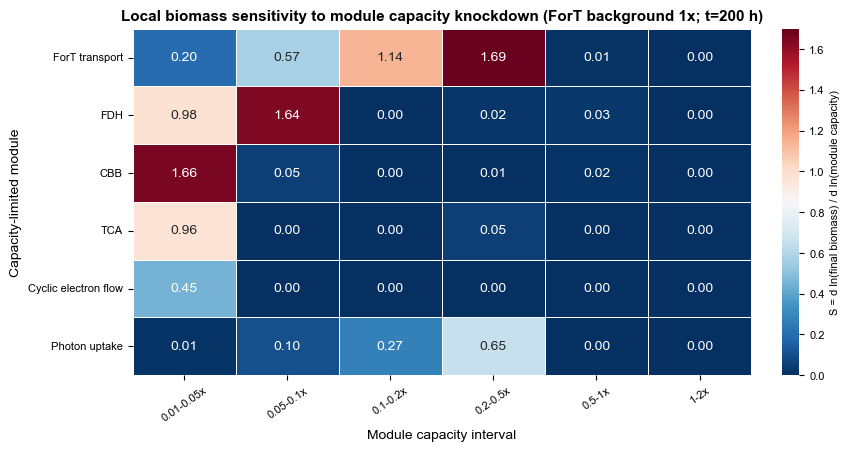

Saved: publication_outputs\mm_dfba_module_biomass_sensitivity_coefficient_heatmap.svg


In [8]:
# Biomass sensitivity coefficient heatmap across adjacent capacity intervals.
# This post-processing step uses the same fixed ForT background and time horizon
# as the module-capacity response heatmap.

SENSITIVITY_MODULES = MODULE_ORDER.copy()
SENSITIVITY_FORT_BACKGROUND = MODULE_FORT_BACKGROUNDS[0]
SENSITIVITY_SCALES = MODULE_SCALES.copy()
SENSITIVITY_DATA_CSV = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_capacity_scaling_response_heatmap_CS_standard_data.csv"
SENSITIVITY_FIG_SVG = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_biomass_sensitivity_coefficient_heatmap.svg"
SENSITIVITY_FIG_PNG = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_biomass_sensitivity_coefficient_heatmap.png"
SENSITIVITY_OUTPUT_DATA_CSV = MM_DFBA_OUTPUT_DIR / "mm_dfba_module_biomass_sensitivity_coefficient_heatmap_data.csv"


def calculate_biomass_sensitivity_coefficients(summary):
    """Calculate local log-elasticity of final biomass across adjacent capacity intervals."""
    summary = summary.copy()
    for column in ["module_scale", "fort_background", "final_biomass_gDW_L"]:
        summary[column] = pd.to_numeric(summary[column], errors="coerce")

    intervals = list(zip(SENSITIVITY_SCALES[:-1], SENSITIVITY_SCALES[1:]))
    columns = [f"{low:g}-{high:g}x" for low, high in intervals]
    sensitivity = pd.DataFrame(index=SENSITIVITY_MODULES, columns=columns, dtype=float)

    for module in SENSITIVITY_MODULES:
        subset = summary[
            (summary["module"] == module)
            & np.isclose(summary["fort_background"], SENSITIVITY_FORT_BACKGROUND)
        ]
        for low, high in intervals:
            y_low = subset.loc[np.isclose(subset["module_scale"], low), "final_biomass_gDW_L"]
            y_high = subset.loc[np.isclose(subset["module_scale"], high), "final_biomass_gDW_L"]
            if y_high.empty or y_low.empty or y_high.iloc[0] <= 0 or y_low.iloc[0] <= 0:
                sensitivity.loc[module, f"{low:g}-{high:g}x"] = np.nan
                continue
            value = (
                np.log(y_high.iloc[0]) - np.log(y_low.iloc[0])
            ) / (np.log(high) - np.log(low))
            sensitivity.loc[module, f"{low:g}-{high:g}x"] = max(0.0, value)

    return sensitivity


def plot_biomass_sensitivity_heatmap(sensitivity, svg_path, png_path):
    """Plot local biomass sensitivity coefficients across module-capacity intervals."""
    max_value = np.nanmax(sensitivity.to_numpy(dtype=float))
    colorbar_max = max(1.0, np.ceil(max_value * 10) / 10)

    fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
    heatmap = sns.heatmap(
        sensitivity,
        ax=ax,
        cmap="RdBu_r",
        vmin=0,
        vmax=colorbar_max,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Biomass sensitivity coefficient"},
    )
    ax.set_xlabel("Module capacity interval")
    ax.set_ylabel("Capacity-limited module")
    ax.set_title(
        f"Local biomass sensitivity to module capacity knockdown "
        f"(ForT background {SENSITIVITY_FORT_BACKGROUND:g}x; t={MODULE_T_MAX_H} h)",
        fontsize=11,
        fontweight="bold",
    )
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=8)
    heatmap.collections[0].colorbar.set_label(
        "S = d ln(final biomass) / d ln(module capacity)",
        fontsize=8,
    )
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()


sensitivity_summary = pd.read_csv(SENSITIVITY_DATA_CSV)
biomass_sensitivity = calculate_biomass_sensitivity_coefficients(sensitivity_summary)
biomass_sensitivity.to_csv(SENSITIVITY_OUTPUT_DATA_CSV, encoding='utf-8-sig')
display(biomass_sensitivity)
plot_biomass_sensitivity_heatmap(
    biomass_sensitivity,
    SENSITIVITY_FIG_SVG,
    SENSITIVITY_FIG_PNG,
)
print(f"Saved: {SENSITIVITY_FIG_SVG}")




## 6) Output manifest

All generated analysis files are listed from the unified `publication_outputs/` directory.


In [9]:
out_files = sorted(p.name for p in OUTPUT_DIR.glob('*') if p.is_file())
print('\n'.join(f'- {name}' for name in out_files))


- Analysis_Linear_Regression.svg
- Analysis_Linear_Regression_data.csv
- Scan_Analysis_Final.svg
- flux_exchange_nonzero.csv
- flux_full.csv
- kinetics.csv
- mm_dfba_20mM_abundance_evolution_bars.svg
- mm_dfba_20mM_abundance_evolution_bars_data.csv
- mm_dfba_20mM_fort_parameter_sensitivity.svg
- mm_dfba_20mM_fort_parameter_sensitivity_data.csv
- mm_dfba_module_biomass_sensitivity_coefficient_heatmap.png
- mm_dfba_module_biomass_sensitivity_coefficient_heatmap.svg
- mm_dfba_module_biomass_sensitivity_coefficient_heatmap_data.csv
- mm_dfba_module_capacity_scaling_response_heatmap.png
- mm_dfba_module_capacity_scaling_response_heatmap.svg
- mm_dfba_module_capacity_scaling_response_heatmap_CS_standard.png
- mm_dfba_module_capacity_scaling_response_heatmap_CS_standard.svg
- mm_dfba_module_capacity_scaling_response_heatmap_CS_standard_data.csv
- mm_enzyme_constrained_dfba_20mM_active_diffusion.svg
- mm_enzyme_constrained_dfba_20mM_active_diffusion_data.csv
- mm_enzyme_constrained_dfba_format